# HI-CSG-R Late Correction v2: полный эксперимент

Этот notebook исполняет frozen protocol v2 по стадиям. Он сохраняет v1,
не открывает holdout до выбора dev-кандидата и не открывает test до положительного
holdout gate. `STOP` является научным результатом, а не ошибкой notebook.


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

start = Path.cwd().resolve()
ROOT = next(
    (
        candidate
        for candidate in (start, *start.parents)
        if (candidate / "src").is_dir() and (candidate / "tools").is_dir()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError(f"Корень репозитория не найден из cwd={start}")
PYTHON = str(ROOT / ".venv/bin/python")
OUT = ROOT / "outputs/htr_adapter_v2"
DATA = ROOT / "data/experiments/htr_adapter_v2"
LOGS = OUT / "notebook/logs"
LOGS.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def show_json(path, title=None):
    value = load_json(path)
    display(Markdown(f"### {title or Path(path).name}"))
    display(value)
    return value

def module(name, *args, log_name=None, allowed=(0,)):
    command = [PYTHON, "-m", name, *map(str, args)]
    label = log_name or name.rsplit(".", 1)[-1]
    log_path = LOGS / f"{label}.stdout.log"
    display(Markdown(f"**RUN `{label}`**\n\n`{' '.join(command)}`"))
    with log_path.open("w", encoding="utf-8") as stream:
        process = subprocess.Popen(
            command,
            cwd=ROOT,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            env=os.environ.copy(),
            bufsize=1,
        )
        assert process.stdout is not None
        for line in process.stdout:
            stream.write(line)
            stream.flush()
            print(line, end="", flush=True)
        returncode = process.wait()
    state = "PASS" if returncode == 0 else "STOP" if returncode == 2 else "FAIL"
    display(Markdown(f"**{state} `{label}`**; log: `{log_path}`"))
    if returncode not in allowed:
        raise RuntimeError(f"{label}: exit={returncode}; log={log_path}")
    return returncode

def resume_args(run_dir):
    run_dir = Path(run_dir)
    return (
        ("--resume", run_dir / "last.pt")
        if (run_dir / "last.pt").exists() and not (run_dir / "train_summary.json").exists()
        else ()
    )

display(Markdown(f"**Workspace:** `{ROOT}`  \n**Python:** `{PYTHON}`"))


**Workspace:** `/home/galetka/Documents/Programming/hi-csg-r`  
**Python:** `/home/galetka/Documents/Programming/hi-csg-r/.venv/bin/python`

## 1. Frozen protocol и неизменность v1


In [2]:
display(Markdown((ROOT / "docs/crnn_ctc_hi_csg_r_late_correction_protocol_v2.md").read_text()))
show_json(OUT / "protocol_freeze/protocol_freeze.json", "Protocol freeze")
display(Markdown(
    "V1 остается отдельным отрицательным результатом: "
    "`outputs/htr_adapter_v1/final_report/full_execution_report_ru.md`."
))


# CRNN-CTC HI-CSG-R Late Correction Protocol v2

**Version:** 2.0  
**Frozen:** 2026-07-30  
**Previous protocol:** `crnn_ctc_hi_csg_r_adapter_protocol_v1`  
**Feature source:** `hi_csg_r_xaligned_v1`  
**Split seed:** `20260730`

## 1. Status of v1

The v1 result remains a completed negative experiment:

```text
M0-FT seed42 validation micro-CER = 0.079537
M3 correct validation micro-CER = 0.082196
M3 shuffled validation micro-CER = 0.083004
M3 relative degradation = 3.342%
correct-vs-shuffled advantage = 0.000808 CER
```

V1 artifacts, stopping decision, and conclusion must not be overwritten.
Blocked v1 runs cannot be restarted under the v1 protocol name.

## 2. Research question

Test whether a bounded HI-CSG-R correction of frozen baseline CTC logits can
reduce CER when intervention is restricted to non-empty graph bins and weighted
by visual uncertainty.

Positive evidence requires:

1. improvement over the matched frozen image-only baseline;
2. correct graph better than matched shuffle;
3. an independent holdout gate;
4. reproducibility on final seeds 42, 43, and 44;
5. one-shot final test evaluation;
6. no material degradation of core domains;
7. exactly zero correction in empty bins.

## 3. Architectural boundary

The image recognizer is unchanged and frozen:

```text
image -> CNN -> projection -> BiLSTM -> classifier -> Z_base
```

The only added path is:

```text
x-aligned HI-CSG-R [T,20]
-> post-normalization empty mask
-> masked pooling at kernels 1/5/9
-> graph adapter [T,128]
-> uncertainty/risk-aware bounded gate
-> delta CTC logits
Z_final = Z_base + alpha * gate * delta
```

CNN, projection, BiLSTM, and baseline classifier remain `requires_grad=False`.
The complete v2 trainable module must contain fewer than 400,000 parameters,
preferably fewer than 250,000.

## 4. Independent development data

The canonical enhanced train set of 39,998 samples is split group-wise:

| Split | Samples | Per-domain target |
|---|---:|---:|
| adapter_v2_train | 35,498 | remainder |
| adapter_v2_dev | 3,000 | 1,000 |
| adapter_v2_holdout | 1,500 | 500 |

Grouping priority:

```text
writer_id
-> source_metadata.page_id / page_id
-> source_group / line_group_id
-> source image
-> normalized image path
-> sample_id
```

Sample ID, image path, exact SHA1, and group overlap must all equal zero.
The normalizer and risk quantiles are fitted only on adapter_v2_train.

A fresh `B0-dev-v2` image-only CRNN-CTC is trained only on adapter_v2_train
and selected only on adapter_v2_dev. Holdout is not evaluated during training.

## 5. Preflight D1-D3

Before v2 training, run inference-only diagnostics on v1:

- D1 blank penalties: `-0.8,-0.6,-0.5,-0.4,-0.3,-0.2,0.0`;
- D2 graph scales: `0,0.10,0.25,0.50,0.75,1.0`;
- D3 strict non-empty graph mask, correct and shuffled.

Preflight freezes the development blank penalty and `alpha_max`.
Default `alpha_max` is 0.25.

Full V2-1/V2-2 development is allowed when correct graph is better than
shuffle, the branch is active, and D2 or D3 improves M3 by at least 0.0005
absolute CER. If the last condition fails, only V2-1 is allowed as a final
architectural check.

## 6. Input masks

The batch contains:

- `time_mask`: real CRNN timestep;
- `nonempty_graph_mask`: local graph/ink is present;
- `padding_mask`: batch-only padding.

Normalization order is mandatory:

```python
x_norm = normalizer.transform(x_raw)
x_norm = x_norm * nonempty_graph_mask[..., None]
```

Post-normalization graph input, graph embedding, delta logits, gate, and final
correction must be exactly zero for every empty real bin and padded timestep.

## 7. Features and risk

All 20 v1 features are retained. `ambiguous_edge_fraction` is diagnostic-only
when its train standard deviation is below `1e-6`.

V2-1:

```text
gate = time * nonempty * uncertainty * learned_gate
```

V2-2:

```text
risk = 0.30*component_scaled
     + 0.40*short_branch_fraction
     + 0.30*warning_scaled
reliability = exp(-2*risk)
gate = time * nonempty * uncertainty * reliability * learned_gate
```

Risk scaling uses train-only q05/q50/q95. Risk attenuation is not described as
a calibrated probability of graph correctness.

## 8. Visual uncertainty

Uncertainty is deterministic and target-free:

```text
p = softmax(Z_base.detach())
entropy = normalized categorical entropy
margin_uncertainty = 1 - (p_top1 - p_top2)
u = clamp(0.5*entropy + 0.5*margin_uncertainty, 0, 1)
```

## 9. Late correction

The correction head consumes detached visual hidden state and graph embedding.
Its final linear layer is initialized to zero.

```text
alpha = alpha_max * sigmoid(alpha_logit)
alpha_logit_init = -6
Z_final = Z_base + alpha * gate * delta_logits
```

With `alpha=0`, max absolute difference from baseline logits must be below
`1e-6`.

## 10. Loss and training

```text
L = CTC(Z_final)
  + lambda_pres * baseline_preservation_KL
  + lambda_aux(epoch) * graph_aux_CTC
```

Preservation temperature is 1.5. Development starts at
`lambda_pres=0.05`. Only the best dev variant may be repeated at 0.10.

Auxiliary schedule:

| Epochs | lambda_aux |
|---|---:|
| 1-3 | 0.15 |
| 4-6 | 0.05 |
| 7+ | 0.00 |

Optimizer is AdamW with LR `3e-4`, weight decay `1e-4`, gradient clipping
`5.0`, and batch size 16. Development has at most 20 epochs, minimum 8,
patience 5, and checkpoint selection by dev micro-CER. A reproducible
domain-balanced sampler approximates one third per core domain.

## 11. Permitted development runs

| ID | Configuration |
|---|---|
| B0-dev-v2 | fresh image-only reduced-train baseline |
| V2-1-dev-p05 | mask + uncertainty, lambda_pres=0.05 |
| V2-2-dev-p05 | V2-1 + risk attenuation |
| V2-best-dev-p10 | at most one repeat of the best variant |

The baseline plus at most three correction runs is the absolute limit.

V2 variant dev gate:

- relative CER improvement at least 1%;
- correct graph better than shuffle;
- no domain worse by more than 0.003 CER;
- Exact decreases by no more than 0.005;
- empty correction max below `1e-7`.

## 12. Holdout

The selected configuration is frozen before one-shot holdout evaluation.
The positive gate requires:

- relative CER improvement at least 2%;
- correct graph better than shuffle;
- at least two of three domains not worse;
- no domain worse by more than 0.003 CER;
- Exact not below baseline;
- WER degradation no more than 0.003.

Failure blocks final seeds and the original test.

## 13. Final protocol

Only after a positive holdout:

1. obtain matched M0-FT checkpoints for seeds 42/43/44;
2. freeze each backbone;
3. train the fixed v2 correction on canonical train;
4. select by canonical validation micro-CER;
5. open final test once after all three seeds are frozen;
6. run correct/shuffle controls and paired bootstrap/Holm analysis.

## 14. Hard stops

Stop before test if any occurs:

- empty correction is nonzero;
- frozen backbone hash changes;
- V2-1 is worse by more than 1% and preflight provides no allowed remedy;
- both V2-1 and V2-2 are worse;
- correct graph is not better than shuffle;
- holdout gate fails;
- two core domains degrade;
- an unregistered alpha/lambda/feature/architecture search is required;
- CNN or BiLSTM must be unfrozen.

After STOP, test, new gates, new encoders, feature changes, and extra
hyperparameter values are prohibited.

## 15. Primary and secondary endpoints

Primary endpoint is micro-CER. Secondary endpoints are macro-CER, WER, Exact,
char/word edits, domain CER, page-disjoint CER, and absolute robustness CER.

Technical behavior, lower CTC loss, nonzero gradients, gate variability,
zero-graph degradation, one-sample overfit, or an isolated small subgroup do
not independently confirm H4-v2.

## 16. Result tiers

- Minimum: holdout relative CER improvement >=2%, correct > shuffle, Exact not
  lower, two domains not worse, at least two of three final seeds improve.
- Clear: mean final test CER improvement >=5%, 3/3 seeds, paired CI below zero,
  no major domain degradation, Exact improves at least one percentage point.
- Strong: mean final test CER improvement >=8%, School/hard improves >=10%,
  3/3 seeds, page-disjoint not worse, most robustness conditions not worse.
- Negative: holdout fails, correct <= shuffle, seed instability, two-domain
  degradation, negligible paired effect, or alpha returns effectively to zero.

## 17. Reproducibility

Required artifacts include configs and hashes, manifests and split hashes,
normalizer, risk quantiles, checkpoints, histories, predictions, shuffle maps,
statistics, evidence manifest, SHA256SUMS, reports, figures, and thesis text.

Any scientific change after this freeze requires a documented protocol
amendment with its reason and must never rewrite v1.



### Protocol freeze

{'protocol': 'crnn_ctc_hi_csg_r_late_correction_protocol_v2',
 'frozen_before_training': True,
 'implementation_commit': '0e8ee2c',
 'preflight_decision': 'CONTINUE_FULL',
 'selected_blank_logit_penalty': -0.4,
 'selected_alpha_max': 0.25,
 'split_seed': 20260730,
 'sha256': {'docs/crnn_ctc_hi_csg_r_late_correction_protocol_v2.md': '77e630be611118ff99e4a3df48962d0e4be9268975b4da3c72fec43baaaa1de5',
  'configs/htr_adapter_v2/b0_dev_seed42.yaml': '6f68c98348995b33fde80377e791293ba4f8aeec740c45c3c8328d5221ae0252',
  'configs/htr_adapter_v2/final_seed42.yaml': 'df8c1609eadb6e4a5477967c6cab8fcb2bdaf128dc2ea5a9a67d2f5c5741754d',
  'configs/htr_adapter_v2/final_seed43.yaml': '6b8957faf3b4c4a58553c3a372c90d58cfc748e0c359a712723dd45e0bbded08',
  'configs/htr_adapter_v2/final_seed44.yaml': 'bf6287bd0e58d3bde2ee4780132744dace853c755b891342ee1503657234d433',
  'configs/htr_adapter_v2/preflight.yaml': '3085d7f7151549ddc2ccd85d0cde75b8678a5c20a6298070af4dccf92b456263',
  'configs/htr_adapter_v2/v2_1

V1 остается отдельным отрицательным результатом: `outputs/htr_adapter_v1/final_report/full_execution_report_ru.md`.

## 2. Tests и статическая проверка


In [3]:
module("pytest", "-q", *sorted(str(path) for path in (ROOT / "tests").glob("test_htr_adapter_v2_*.py")), log_name="pytest_v2")
v2_tools = sorted({
    str(path)
    for pattern in (
        "*hi_csg_r*adapter*v2*.py",
        "*hi_csg_r*late_correction*v2*.py",
        "train_crnn_ctc_adapter_v2_baseline.py",
        "prepare_hi_csg_r_adapter_v2_features.py",
    )
    for path in (ROOT / "tools").glob(pattern)
})
module(
    "ruff", "check",
    "src/htr/adapter_runtime_v2.py",
    "src/htr/dataset_adapter_v2.py",
    "src/htr/losses_adapter_v2.py",
    "src/htr/masked_pooling.py",
    "src/htr/model_hi_csg_r_late_correction_v2.py",
    "src/htr/uncertainty.py",
    *v2_tools,
    log_name="ruff_v2",
)


**RUN `pytest_v2`**

`/home/galetka/Documents/Programming/hi-csg-r/.venv/bin/python -m pytest -q /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_checkpoint.py /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_losses.py /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_masking.py /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_model.py /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_pooling.py /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_risk.py /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_split.py /home/galetka/Documents/Programming/hi-csg-r/tests/test_htr_adapter_v2_uncertainty.py`

........................                                                 [100%]


24 passed in 2.66s


**PASS `pytest_v2`**; log: `/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/notebook/logs/pytest_v2.stdout.log`

**RUN `ruff_v2`**

`/home/galetka/Documents/Programming/hi-csg-r/.venv/bin/python -m ruff check src/htr/adapter_runtime_v2.py src/htr/dataset_adapter_v2.py src/htr/losses_adapter_v2.py src/htr/masked_pooling.py src/htr/model_hi_csg_r_late_correction_v2.py src/htr/uncertainty.py /home/galetka/Documents/Programming/hi-csg-r/tools/analyze_hi_csg_r_adapter_v2_failures.py /home/galetka/Documents/Programming/hi-csg-r/tools/audit_hi_csg_r_adapter_v2_split.py /home/galetka/Documents/Programming/hi-csg-r/tools/build_hi_csg_r_adapter_v2_shuffle_map.py /home/galetka/Documents/Programming/hi-csg-r/tools/build_hi_csg_r_late_correction_v2_notebook.py /home/galetka/Documents/Programming/hi-csg-r/tools/check_hi_csg_r_adapter_v2_smoke.py /home/galetka/Documents/Programming/hi-csg-r/tools/compare_hi_csg_r_adapter_v2_results.py /home/galetka/Documents/Programming/hi-csg-r/tools/create_hi_csg_r_adapter_v2_smoke_manifests.py /home/galetka/Documents/Programming/hi-csg-r/tools/create_hi_csg_r_adapter_v2_split.py /home/galetka/Documents/Programming/hi-csg-r/tools/diagnose_hi_csg_r_adapter_v1_for_v2.py /home/galetka/Documents/Programming/hi-csg-r/tools/evaluate_crnn_ctc_hi_csg_r_late_correction_v2.py /home/galetka/Documents/Programming/hi-csg-r/tools/make_hi_csg_r_adapter_v2_final_report.py /home/galetka/Documents/Programming/hi-csg-r/tools/materialize_hi_csg_r_adapter_v2_baseline_predictions.py /home/galetka/Documents/Programming/hi-csg-r/tools/paired_bootstrap_hi_csg_r_adapter_v2.py /home/galetka/Documents/Programming/hi-csg-r/tools/prepare_hi_csg_r_adapter_v2_features.py /home/galetka/Documents/Programming/hi-csg-r/tools/resolve_hi_csg_r_adapter_v2_final_configs.py /home/galetka/Documents/Programming/hi-csg-r/tools/select_hi_csg_r_adapter_v2_candidate.py /home/galetka/Documents/Programming/hi-csg-r/tools/summarize_hi_csg_r_adapter_v2_final_statistics.py /home/galetka/Documents/Programming/hi-csg-r/tools/train_crnn_ctc_adapter_v2_baseline.py /home/galetka/Documents/Programming/hi-csg-r/tools/train_crnn_ctc_hi_csg_r_late_correction_v2.py`

All checks passed!


**PASS `ruff_v2`**; log: `/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/notebook/logs/ruff_v2.stdout.log`

0

## 3. Preflight D1-D3


### Preflight decision

{'decision': {'status': 'CONTINUE_FULL',
  'selected_blank_logit_penalty': -0.4,
  'selected_alpha_max': 0.25,
  'best_v1_graph_scale': 0.0,
  'd2_absolute_cer_gain': 0.000808132363574493,
  'd3_absolute_cer_gain': -0.00019139977032027466,
  'correct_better_strict_shuffle': True,
  'branch_technically_active': True,
  'allow_v2_2': True},
 'blank_penalty': {'m0_ft': {'-0.8': {'samples': 6000,
    'cer': 0.07979243758240824,
    'macro_cer': 0.08553180136771005,
    'wer': 0.3323977546110666,
    'exact': 0.6268333333333334,
    'char_edits': 3752,
    'target_chars': 47022,
    'word_edits': 2487,
    'target_words': 7482,
    'pred_len_mean': 7.8005},
   '-0.6': {'samples': 6000,
    'cer': 0.07977117094126154,
    'macro_cer': 0.08536721339218942,
    'wer': 0.33279871692060947,
    'exact': 0.6265,
    'char_edits': 3751,
    'target_chars': 47022,
    'word_edits': 2490,
    'target_words': 7482,
    'pred_len_mean': 7.7941666666666665},
   '-0.5': {'samples': 6000,
    'cer': 0.07

,model,penalty,cer,wer,exact
0,m0_ft,-0.8,0.079792,0.332398,0.626833
1,m0_ft,-0.6,0.079771,0.332799,0.626500
2,m0_ft,-0.5,0.079559,0.331997,0.627333
3,m0_ft,-0.4,0.079537,0.332398,0.626833
4,m0_ft,-0.3,0.079559,0.332531,0.626833
5,m0_ft,-0.2,0.079601,0.332799,0.626333
6,m0_ft,0.0,0.079686,0.333734,0.625500
7,m3,-0.8,0.082217,0.336942,0.621167
8,m3,-0.6,0.082302,0.337209,0.620833
9,m3,-0.5,0.082153,0.336942,0.621000


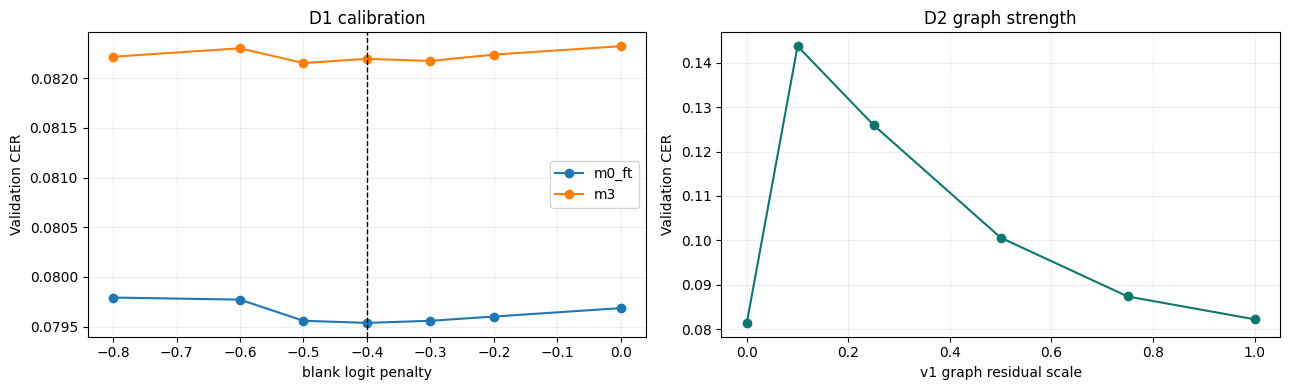

In [4]:
preflight_path = OUT / "preflight/preflight_report.json"
if not preflight_path.exists():
    module(
        "tools.diagnose_hi_csg_r_adapter_v1_for_v2",
        "--m0_checkpoint", "outputs/htr_adapter_v1/m0_ft_seed42/best.pt",
        "--m3_checkpoint", "outputs/htr_adapter_v1/m3_full_seed42/best.pt",
        "--manifest", "data/experiments/htr_adapter_v1/manifests/val.jsonl",
        "--shuffle_map", "data/experiments/htr_adapter_v1/shuffle_maps/val_seed42.json",
        "--vocab", "data/experiments/htr_baseline_v1_ctc_ready/tri10k_mixed_plus_school_lines_10k_context_v1/vocab.json",
        "--normalizer", "data/experiments/htr_adapter_v1/normalizer/train_stats.json",
        "--out_dir", preflight_path.parent,
        allowed=(0, 2),
    )
preflight = show_json(preflight_path, "Preflight decision")
penalty_table = pd.read_csv(OUT / "preflight/blank_penalty_sweep.csv")
display(penalty_table)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, values in preflight["blank_penalty"].items():
    xs = sorted(float(value) for value in values)
    axes[0].plot(
        xs,
        [values[str(value)]["cer"] for value in xs],
        marker="o",
        label=model,
    )
axes[0].axvline(
    preflight["decision"]["selected_blank_logit_penalty"],
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set(xlabel="blank logit penalty", ylabel="Validation CER", title="D1 calibration")
axes[0].legend()
scale_values = preflight["graph_scale"]
scale_x = sorted(float(value) for value in scale_values)
axes[1].plot(
    scale_x,
    [scale_values[str(value)]["cer"] for value in scale_x],
    marker="o",
    color="#0f766e",
)
axes[1].set(xlabel="v1 graph residual scale", ylabel="Validation CER", title="D2 graph strength")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 4. Independent split и train-only statistics


In [5]:
split_audit = OUT / "split_audit/split_audit.json"
if not split_audit.exists():
    module(
        "tools.create_hi_csg_r_adapter_v2_split",
        "--train_manifest", "data/experiments/htr_adapter_v1/manifests/train.jsonl",
        "--out_dir", DATA / "splits",
        "--features_out_dir", DATA / "features",
        "--dev_per_domain", 1000,
        "--holdout_per_domain", 500,
        "--seed", 20260730,
    )
    module(
        "tools.audit_hi_csg_r_adapter_v2_split",
        "--split_dir", DATA / "splits",
        "--out_dir", split_audit.parent,
    )
feature_audit = OUT / "feature_audit/feature_audit.json"
if not feature_audit.exists():
    module(
        "tools.prepare_hi_csg_r_adapter_v2_features",
        "--train_manifest", DATA / "features/train.jsonl",
        "--dev_manifest", DATA / "features/dev.jsonl",
        "--holdout_manifest", DATA / "features/holdout.jsonl",
        "--normalizer_out", DATA / "normalizer/train_stats.json",
        "--risk_stats_out", DATA / "normalizer/risk_stats.json",
        "--audit_out", feature_audit,
        log_name="prepare_v2_features",
    )
show_json(split_audit, "Split audit")
show_json(feature_audit, "Feature/normalizer audit")


### Split audit

{'status': 'PASS',
 'counts': {'train': 35498, 'dev': 3000, 'holdout': 1500},
 'domain_counts': {'train': {'cyrillic': 8500, 'hkr': 8500, 'school': 18498},
  'dev': {'cyrillic': 1000, 'hkr': 1000, 'school': 1000},
  'holdout': {'cyrillic': 500, 'hkr': 500, 'school': 500}},
 'duplicate_sample_ids': {'train': 0, 'dev': 0, 'holdout': 0},
 'missing_images': {'train': 0, 'dev': 0, 'holdout': 0},
 'missing_features': {'train': 0, 'dev': 0, 'holdout': 0},
 'overlaps': {'sample_id': {'train_dev': 0,
   'train_holdout': 0,
   'dev_holdout': 0},
  'image_path': {'train_dev': 0, 'train_holdout': 0, 'dev_holdout': 0},
  'group': {'train_dev': 0, 'train_holdout': 0, 'dev_holdout': 0},
  'image_sha1': {'train_dev': 0, 'train_holdout': 0, 'dev_holdout': 0}},
 'near_duplicate_audit': {'status': 'NOT_AVAILABLE',
  'note': 'No frozen perceptual-hash infrastructure exists; exact SHA1 overlap is enforced.'},
 'failures': []}

### Feature/normalizer audit

{'status': 'PASS',
 'normalizer_fit_split': 'train',
 'train_records': 35498,
 'train_bins': 2575073,
 'split_counts': {'train': 35498, 'dev': 3000, 'holdout': 1500},
 'split_audits': {'train': {'manifest': '/home/galetka/Documents/Programming/hi-csg-r/data/experiments/htr_adapter_v2/splits/train.jsonl',
   'records': 35498,
   'valid_bins': 2575073,
   'nonfinite_records': 0,
   'feature_name_mismatches': 0},
  'dev': {'manifest': '/home/galetka/Documents/Programming/hi-csg-r/data/experiments/htr_adapter_v2/splits/dev.jsonl',
   'records': 3000,
   'valid_bins': 229404,
   'nonfinite_records': 0,
   'feature_name_mismatches': 0},
  'holdout': {'manifest': '/home/galetka/Documents/Programming/hi-csg-r/data/experiments/htr_adapter_v2/splits/holdout.jsonl',
   'records': 1500,
   'valid_bins': 120132,
   'nonfinite_records': 0,
   'feature_name_mismatches': 0}},
 'inactive_features': [],
 'ambiguous_edge_fraction_active': True,
 'risk_stats': {'feature_names': ['component_count_norm',
  

{'status': 'PASS',
 'normalizer_fit_split': 'train',
 'train_records': 35498,
 'train_bins': 2575073,
 'split_counts': {'train': 35498, 'dev': 3000, 'holdout': 1500},
 'split_audits': {'train': {'manifest': '/home/galetka/Documents/Programming/hi-csg-r/data/experiments/htr_adapter_v2/splits/train.jsonl',
   'records': 35498,
   'valid_bins': 2575073,
   'nonfinite_records': 0,
   'feature_name_mismatches': 0},
  'dev': {'manifest': '/home/galetka/Documents/Programming/hi-csg-r/data/experiments/htr_adapter_v2/splits/dev.jsonl',
   'records': 3000,
   'valid_bins': 229404,
   'nonfinite_records': 0,
   'feature_name_mismatches': 0},
  'holdout': {'manifest': '/home/galetka/Documents/Programming/hi-csg-r/data/experiments/htr_adapter_v2/splits/holdout.jsonl',
   'records': 1500,
   'valid_bins': 120132,
   'nonfinite_records': 0,
   'feature_name_mismatches': 0}},
 'inactive_features': [],
 'ambiguous_edge_fraction_active': True,
 'risk_stats': {'feature_names': ['component_count_norm',
  

## 5. Smoke/overfit gate


In [6]:
smoke = show_json(OUT / "smoke/smoke_gate.json", "Smoke gate")
if smoke["status"] != "PASS":
    display(Markdown("**STOP:** full development запрещен до исправления программной ошибки."))


### Smoke gate

{'status': 'PASS',
 'conditions': {'one_sample_cer_zero': True,
  'finite_losses': True,
  'graph_gradient_nonzero': True,
  'gate_nonconstant': True,
  'correct_not_worse_shuffle': True,
  'empty_correction_zero': True,
  'backbone_unchanged': True,
  'no_blank_collapse': True},
 'one_sample': {'cer': 0.0, 'exact': 1.0},
 'subset': {'cer': 0.0,
  'exact': 1.0,
  'gate_std': 0.03159103915095329,
  'correct_cer': 0.0,
  'shuffle_cer': 0.0,
  'empty_correction_max': 0.0,
  'blank_ratio': 0.7681600695954763}}

## 6. Fresh B0-dev-v2


### B0-dev-v2 training

{'experiment_id': 'htr_adapter_v2_b0_dev_seed42',
 'mode': 'b0_dev',
 'seed': 42,
 'best_dev_micro_cer': 0.13947486239498566,
 'epochs_completed': 80,
 'runtime_seconds': 14199.999373731,
 'holdout_evaluated': False,
 'device': 'cuda',
 'torch': '2.6.0+cu124',
 'cuda': '12.4',
 'platform': 'Linux-6.12.96+deb13-amd64-x86_64-with-glibc2.41',
 'python': '3.11.12 (main, Apr  9 2025, 04:04:00) [Clang 20.1.0 ]',
 'parameters': 3900892}

,epoch,train_loss,blank_logit_penalty,val_CER,val_macro_CER,val_WER,val_exact,val_blank_ratio
75,76,0.044708,-0.481013,0.139475,0.129285,0.480571,0.423667,0.793953
76,77,0.043573,-0.460759,0.140212,0.130095,0.479077,0.423000,0.792650
77,78,0.041096,-0.440506,0.142951,0.134221,0.493856,0.406667,0.789786
78,79,0.043449,-0.420253,0.140950,0.130659,0.480073,0.424667,0.790714
79,80,0.042488,-0.400000,0.145953,0.137085,0.500166,0.399000,0.790740


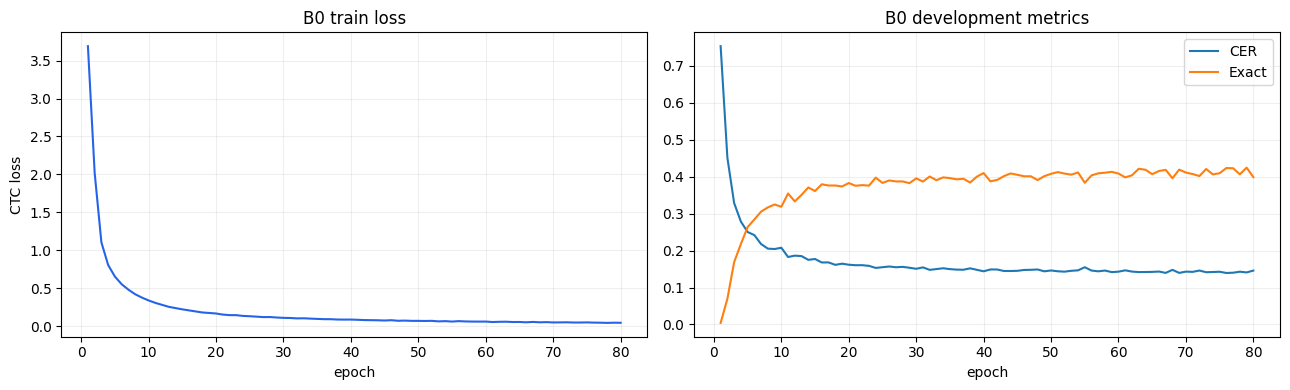

In [7]:
b0 = OUT / "b0_dev_seed42/train_summary.json"
if smoke["status"] == "PASS" and not b0.exists():
    module(
        "tools.train_crnn_ctc_adapter_v2_baseline",
        "train", "--config", "configs/htr_adapter_v2/b0_dev_seed42.yaml",
        *resume_args(OUT / "b0_dev_seed42"),
        log_name="b0_dev_seed42",
    )
if b0.exists():
    show_json(b0, "B0-dev-v2 training")
    b0_history = pd.DataFrame(load_json(OUT / "b0_dev_seed42/history.json"))
    display(b0_history.tail())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(b0_history["epoch"], b0_history["train_loss"], color="#2563eb")
    axes[0].set(title="B0 train loss", xlabel="epoch", ylabel="CTC loss")
    axes[1].plot(b0_history["epoch"], b0_history["val_CER"], label="CER")
    axes[1].plot(b0_history["epoch"], b0_history["val_exact"], label="Exact")
    axes[1].set(title="B0 development metrics", xlabel="epoch")
    axes[1].legend()
    for axis in axes:
        axis.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("B0 не запущен из-за предыдущего STOP."))


## 7. V2-1 development


### V2-1 training

{'experiment_id': 'htr_adapter_v2_v2_1_dev_p05_seed42',
 'variant': 'v2_1',
 'seed': 42,
 'best_val_cer': 0.13910615996418318,
 'best_epoch': 1,
 'epochs_completed': 8,
 'runtime_seconds': 667.071748383998,
 'best_checkpoint': '/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/v2_1_dev_p05_seed42/best.pt',
 'backbone_unchanged': True,
 'device': 'cuda',
 'torch': '2.6.0+cu124',
 'cuda': '12.4',
 'platform': 'Linux-6.12.96+deb13-amd64-x86_64-with-glibc2.41',
 'python': '3.11.12 (main, Apr  9 2025, 04:04:00) [Clang 20.1.0 ]',
 'trainable_parameters': 196156,
 'v2_module_parameters': 196156,
 'total_parameters': 4097048,
 'initial_backbone_sha256': '02a6772823cb334055060a3025801051bba6344134568b7664d26ed4b542195a'}

,epoch,train_total_loss,train_ctc_loss,train_preservation_kl,train_auxiliary_ctc,lambda_auxiliary,graph_adapter_grad_norm,empty_correction_max,alpha,val_CER,val_macro_CER,val_WER,val_exact,val_alpha,val_gate,val_uncertainty,val_risk,val_intervention,val_correction,backbone_sha256
3,4,0.206782,0.026365,0.000186,3.608153,0.05,0.106783,0.0,0.000989,0.139370,0.129962,0.481900,0.422000,0.000989,"{'mean': 0.022088607773184776, 'std': 0.083171...","{'mean': 0.024386592209339142, 'std': 0.091128...","{'mean': 0.16142112016677856, 'std': 0.1520653...",{'top1_frame_change_rate': 0.00427193946051507...,"{'absolute': {'mean': 0.038566481322050095, 's...",02a6772823cb334055060a3025801051bba6344134568b...
4,5,0.204410,0.027089,0.000255,3.546169,0.05,0.109586,0.0,0.001041,0.139317,0.129866,0.482066,0.422000,0.001041,"{'mean': 0.016996389254927635, 'std': 0.066946...","{'mean': 0.024386592209339142, 'std': 0.091128...","{'mean': 0.16142112016677856, 'std': 0.1520653...",{'top1_frame_change_rate': 0.00408013809698174...,"{'absolute': {'mean': 0.03879881650209427, 'st...",02a6772823cb334055060a3025801051bba6344134568b...
5,6,0.199894,0.026432,0.000326,3.468911,0.05,0.108605,0.0,0.001098,0.139291,0.130020,0.482896,0.420333,0.001098,"{'mean': 0.017965080216526985, 'std': 0.070059...","{'mean': 0.024386592209339142, 'std': 0.091128...","{'mean': 0.16142112016677856, 'std': 0.1520653...",{'top1_frame_change_rate': 0.00516991857160293...,"{'absolute': {'mean': 0.055542849004268646, 's...",02a6772823cb334055060a3025801051bba6344134568b...
6,7,0.026251,0.026233,0.000347,3.511824,0.00,0.003010,0.0,0.001134,0.139238,0.129857,0.481402,0.422000,0.001134,"{'mean': 0.01478496752679348, 'std': 0.0613152...","{'mean': 0.024386592209339142, 'std': 0.091128...","{'mean': 0.16142112016677856, 'std': 0.1520653...",{'top1_frame_change_rate': 0.00455092326201809...,"{'absolute': {'mean': 0.050749652087688446, 's...",02a6772823cb334055060a3025801051bba6344134568b...
7,8,0.026503,0.026481,0.000427,3.606349,0.00,0.003504,0.0,0.001194,0.139422,0.130125,0.482398,0.421667,0.001194,"{'mean': 0.01567836105823517, 'std': 0.0640835...","{'mean': 0.024386592209339142, 'std': 0.091128...","{'mean': 0.16142112016677856, 'std': 0.1520653...",{'top1_frame_change_rate': 0.00561890812714686...,"{'absolute': {'mean': 0.06315348297357559, 'st...",02a6772823cb334055060a3025801051bba6344134568b...


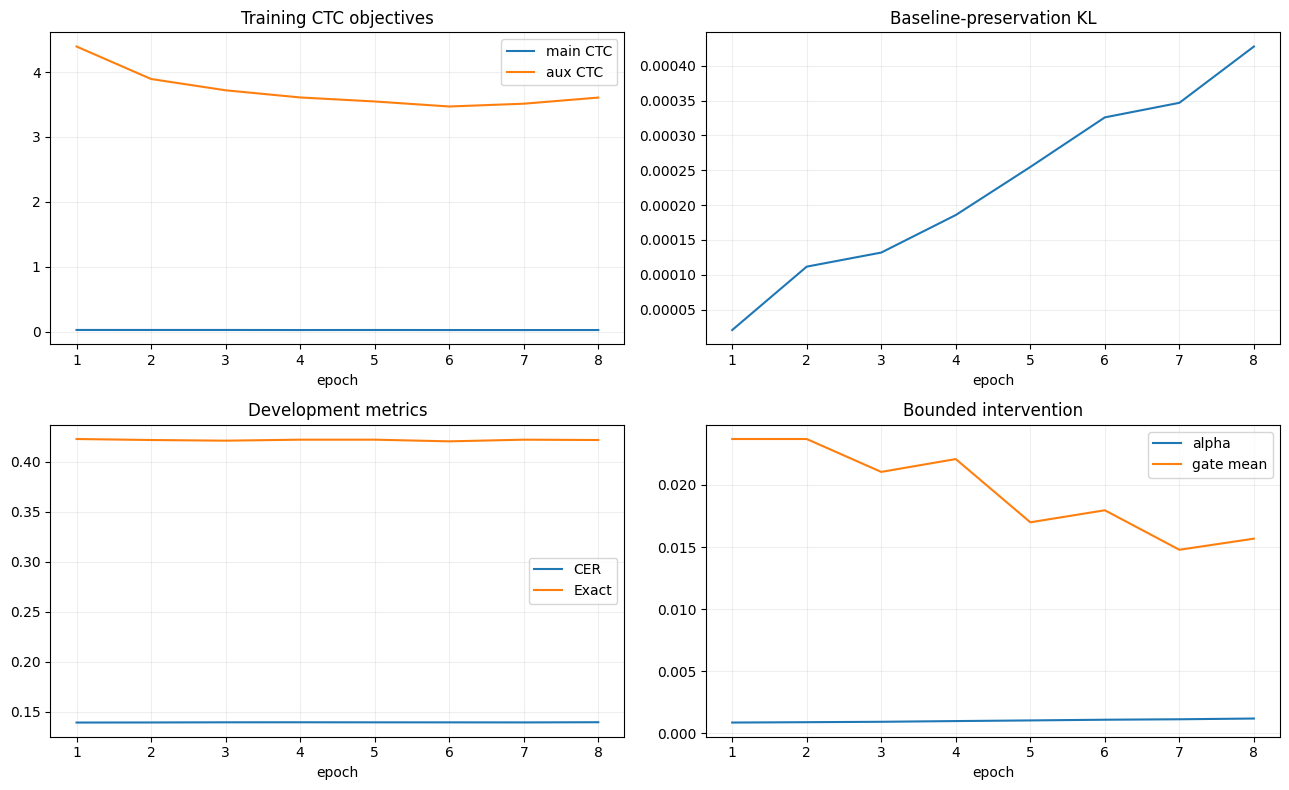

In [8]:
v21 = OUT / "v2_1_dev_p05_seed42/train_summary.json"
if b0.exists() and not v21.exists():
    module(
        "tools.train_crnn_ctc_hi_csg_r_late_correction_v2",
        "train", "--config", "configs/htr_adapter_v2/v2_1_dev_p05_seed42.yaml",
        *resume_args(OUT / "v2_1_dev_p05_seed42"),
        log_name="v2_1_dev_p05",
    )
if v21.exists():
    show_json(v21, "V2-1 training")
    v21_history = pd.DataFrame(
        load_json(OUT / "v2_1_dev_p05_seed42/history.json")
    )
    display(v21_history.tail())
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes[0, 0].plot(v21_history["epoch"], v21_history["train_ctc_loss"], label="main CTC")
    axes[0, 0].plot(v21_history["epoch"], v21_history["train_auxiliary_ctc"], label="aux CTC")
    axes[0, 0].set_title("Training CTC objectives")
    axes[0, 0].legend()
    axes[0, 1].plot(v21_history["epoch"], v21_history["train_preservation_kl"])
    axes[0, 1].set_title("Baseline-preservation KL")
    axes[1, 0].plot(v21_history["epoch"], v21_history["val_CER"], label="CER")
    axes[1, 0].plot(v21_history["epoch"], v21_history["val_exact"], label="Exact")
    axes[1, 0].set_title("Development metrics")
    axes[1, 0].legend()
    axes[1, 1].plot(v21_history["epoch"], v21_history["val_alpha"], label="alpha")
    axes[1, 1].plot(
        v21_history["epoch"],
        [row["mean"] for row in v21_history["val_gate"]],
        label="gate mean",
    )
    axes[1, 1].set_title("Bounded intervention")
    axes[1, 1].legend()
    for axis in axes.flat:
        axis.grid(alpha=0.2)
        axis.set_xlabel("epoch")
    plt.tight_layout()
    plt.show()


## 8. V2-1 correct/shuffle/zero и dev gate


In [9]:
def evaluate_modes(run_dir, manifest, split_name):
    shuffle_map = DATA / f"shuffle_maps/{split_name}_seed42.json"
    if not shuffle_map.exists():
        module(
            "tools.build_hi_csg_r_adapter_v2_shuffle_map",
            "--manifest", manifest, "--seed", 42, "--out", shuffle_map,
            log_name=f"shuffle_{split_name}",
        )
    root = OUT / f"development/{run_dir.name}"
    for mode in ("correct", "shuffle", "zero"):
        destination = root / mode
        if not (destination / "summary.json").exists():
            extra = ("--shuffle_map", shuffle_map) if mode == "shuffle" else ()
            module(
                "tools.evaluate_crnn_ctc_hi_csg_r_late_correction_v2",
                "--checkpoint", run_dir / "best.pt",
                "--manifest", manifest,
                "--mode", mode,
                *extra,
                "--out_dir", destination,
                log_name=f"eval_{run_dir.name}_{mode}",
            )
    return root

v21_eval = None
v21_decision = None
if v21.exists():
    v21_eval = evaluate_modes(OUT / "v2_1_dev_p05_seed42", DATA / "features/dev.jsonl", "dev")
    decision_dir = OUT / "development/v2_1_dev_p05_seed42/decision"
    module(
        "tools.compare_hi_csg_r_adapter_v2_results",
        "--stage", "dev",
        "--correct", v21_eval / "correct",
        "--shuffle", v21_eval / "shuffle",
        "--zero", v21_eval / "zero",
        "--out_dir", decision_dir,
        log_name="v2_1_dev_gate",
        allowed=(0, 2),
    )
    v21_decision = show_json(decision_dir / "dev_decision.json", "V2-1 dev gate")


**RUN `v2_1_dev_gate`**

`/home/galetka/Documents/Programming/hi-csg-r/.venv/bin/python -m tools.compare_hi_csg_r_adapter_v2_results --stage dev --correct /home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/development/v2_1_dev_p05_seed42/correct --shuffle /home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/development/v2_1_dev_p05_seed42/shuffle --zero /home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/development/v2_1_dev_p05_seed42/zero --out_dir /home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/development/v2_1_dev_p05_seed42/decision`

{


  "stage": "dev",


  "status": "STOP",


  "conditions": {


...

  "empty_correction_max": 0.0


}


**STOP `v2_1_dev_gate`**; log: `/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/notebook/logs/v2_1_dev_gate.stdout.log`

### V2-1 dev gate

{'stage': 'dev',
 'status': 'STOP',
 'conditions': {'relative_cer_improvement_at_least_1_percent': False,
  'correct_better_shuffle': False,
  'empty_correction_invariant': True,
  'no_domain_degrades_over_0_003': True,
  'exact_drop_at_most_0_005': True},
 'baseline': {'cer': 0.1393695188433278,
  'wer': 0.47990700763865823,
  'exact': 0.423},
 'correct': {'cer': 0.13910615996418318,
  'wer': 0.4814015277316506,
  'exact': 0.4226666666666667},
 'shuffle': {'cer': 0.13910615996418318,
  'wer': 0.48073729657920955,
  'exact': 0.423},
 'zero': {'cer': 0.1393695188433278,
  'wer': 0.47990700763865823,
  'exact': 0.423},
 'relative_cer_improvement': 0.0018896447467875981,
 'absolute_cer_delta': -0.00026335887914460954,
 'correct_vs_shuffle_cer': 0.0,
 'domain_cer_deltas': {'cyrillic': 0.0005340453938584705,
  'hkr': 0.0007731294562322855,
  'school': -0.0012208067940552014},
 'alpha': 0.0008702169870957732,
 'empty_correction_max': 0.0}

## 9. Условный V2-2 и максимум один p10 repeat


In [10]:
allow_v22 = (
    preflight["decision"]["allow_v2_2"]
    and v21_decision is not None
    and not (
        v21_decision["relative_cer_improvement"] < -0.01
        and preflight["decision"]["d3_absolute_cer_gain"] < 0.0005
    )
)
v22 = OUT / "v2_2_dev_p05_seed42/train_summary.json"
if allow_v22 and not v22.exists():
    module(
        "tools.train_crnn_ctc_hi_csg_r_late_correction_v2",
        "train", "--config", "configs/htr_adapter_v2/v2_2_dev_p05_seed42.yaml",
        *resume_args(OUT / "v2_2_dev_p05_seed42"),
        log_name="v2_2_dev_p05",
    )
if not allow_v22:
    display(Markdown("V2-2 заблокирован frozen preflight/dev stopping rule."))
v22_eval = None
v22_decision = None
if v22.exists():
    v22_eval = evaluate_modes(
        OUT / "v2_2_dev_p05_seed42",
        DATA / "features/dev.jsonl",
        "dev",
    )
    v22_decision_dir = OUT / "development/v2_2_dev_p05_seed42/decision"
    if not (v22_decision_dir / "dev_decision.json").exists():
        module(
            "tools.compare_hi_csg_r_adapter_v2_results",
            "--stage", "dev",
            "--correct", v22_eval / "correct",
            "--shuffle", v22_eval / "shuffle",
            "--zero", v22_eval / "zero",
            "--out_dir", v22_decision_dir,
            log_name="v2_2_dev_gate",
            allowed=(0, 2),
        )
    v22_decision = show_json(
        v22_decision_dir / "dev_decision.json",
        "V2-2 dev gate",
    )

p05_selection_path = OUT / "development/p05_selection.json"
p05_candidates = []
if v21_eval:
    p05_candidates += ["--candidate", f"v2_1_p05={v21_eval}"]
if v22_eval:
    p05_candidates += ["--candidate", f"v2_2_p05={v22_eval}"]
if p05_candidates and not p05_selection_path.exists():
    module(
        "tools.select_hi_csg_r_adapter_v2_candidate",
        "select", *p05_candidates,
        "--purpose", "select_best_p05_before_single_p10_repeat",
        "--out", p05_selection_path,
        log_name="select_p05",
        allowed=(0, 2),
    )
p05_selection = (
    show_json(p05_selection_path, "P05 selection")
    if p05_selection_path.exists()
    else None
)

p10 = OUT / "v2_best_dev_p10_seed42/train_summary.json"
p10_eval = None
if p05_selection and p05_selection["status"] == "PASS":
    resolved_p10 = OUT / "development/resolved_v2_best_dev_p10_seed42.yaml"
    if not resolved_p10.exists():
        module(
            "tools.select_hi_csg_r_adapter_v2_candidate",
            "resolve-p10",
            "--selection", p05_selection_path,
            "--template", "configs/htr_adapter_v2/v2_best_dev_p10_seed42.yaml",
            "--out", resolved_p10,
            log_name="resolve_p10",
        )
    if not p10.exists():
        module(
            "tools.train_crnn_ctc_hi_csg_r_late_correction_v2",
            "train", "--config", resolved_p10,
            *resume_args(OUT / "v2_best_dev_p10_seed42"),
            log_name="v2_best_dev_p10",
        )
    if p10.exists():
        p10_eval = evaluate_modes(
            OUT / "v2_best_dev_p10_seed42",
            DATA / "features/dev.jsonl",
            "dev",
        )
        p10_decision_dir = OUT / "development/v2_best_dev_p10_seed42/decision"
        if not (p10_decision_dir / "dev_decision.json").exists():
            module(
                "tools.compare_hi_csg_r_adapter_v2_results",
                "--stage", "dev",
                "--correct", p10_eval / "correct",
                "--shuffle", p10_eval / "shuffle",
                "--zero", p10_eval / "zero",
                "--out_dir", p10_decision_dir,
                log_name="v2_best_p10_dev_gate",
                allowed=(0, 2),
            )
        show_json(p10_decision_dir / "dev_decision.json", "P10 dev gate")


### V2-2 dev gate

{'stage': 'dev',
 'status': 'STOP',
 'conditions': {'relative_cer_improvement_at_least_1_percent': False,
  'correct_better_shuffle': False,
  'empty_correction_invariant': True,
  'no_domain_degrades_over_0_003': True,
  'exact_drop_at_most_0_005': True},
 'baseline': {'cer': 0.1393695188433278,
  'wer': 0.47990700763865823,
  'exact': 0.423},
 'correct': {'cer': 0.13905348818835428,
  'wer': 0.48206575888409164,
  'exact': 0.423},
 'shuffle': {'cer': 0.13871112164546628,
  'wer': 0.4814015277316506,
  'exact': 0.4226666666666667},
 'zero': {'cer': 0.1393695188433278,
  'wer': 0.47990700763865823,
  'exact': 0.423},
 'relative_cer_improvement': 0.002267573696144998,
 'absolute_cer_delta': -0.0003160306549735148,
 'correct_vs_shuffle_cer': 0.0003423665428879952,
 'domain_cer_deltas': {'cyrillic': 0.0002670226969292422,
  'hkr': 0.0009449360020616776,
  'school': -0.0013269639065817407},
 'alpha': 0.0010677630780264735,
 'empty_correction_max': 0.0}

### P05 selection

{'protocol': 'crnn_ctc_hi_csg_r_late_correction_protocol_v2',
 'purpose': 'select_best_p05_before_single_p10_repeat',
 'created_at': '2026-07-30T19:56:20.472877+00:00',
 'selection_metric': 'development micro-CER',
 'holdout_used': False,
 'test_used': False,
 'status': 'STOP',
 'selected': None,
 'candidates': [{'name': 'v2_1_p05',
   'evaluation_dir': '/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/development/v2_1_dev_p05_seed42',
   'checkpoint': '/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/v2_1_dev_p05_seed42/best.pt',
   'checkpoint_sha256': 'b9b63c54265ab3b1e0d55aceb33f7ed68ffd2bcbcea906fdfd5adeba1826ea61',
   'variant': 'v2_1',
   'lambda_preservation': 0.05,
   'decision': {'stage': 'dev',
    'status': 'STOP',
    'conditions': {'relative_cer_improvement_at_least_1_percent': False,
     'correct_better_shuffle': False,
     'empty_correction_invariant': True,
     'no_domain_degrades_over_0_003': True,
     'exact_drop_at_most_0_00

## 10. Freeze кандидата и one-shot holdout


In [11]:
selection_path = OUT / "development/selected_candidate.json"
final_candidates = []
if v21_eval:
    final_candidates += ["--candidate", f"v2_1_p05={v21_eval}"]
if v22_eval:
    final_candidates += ["--candidate", f"v2_2_p05={v22_eval}"]
if p10_eval:
    final_candidates += ["--candidate", f"best_p10={p10_eval}"]
if final_candidates and not selection_path.exists():
    module(
        "tools.select_hi_csg_r_adapter_v2_candidate",
        "select", *final_candidates,
        "--purpose", "freeze_candidate_before_one_shot_holdout",
        "--out", selection_path,
        log_name="freeze_dev_candidate",
        allowed=(0, 2),
    )
selected = (
    show_json(selection_path, "Frozen selected candidate")
    if selection_path.exists()
    else None
)
if selected:
    dev_rows = []
    for candidate in selected["candidates"]:
        decision = candidate["decision"]
        dev_rows.append({
            "candidate": candidate["name"],
            "gate": decision["status"],
            "baseline_CER": decision["baseline"]["cer"],
            "correct_CER": decision["correct"]["cer"],
            "shuffle_CER": decision["shuffle"]["cer"],
            "zero_CER": decision["zero"]["cer"],
            "relative_improvement": decision["relative_cer_improvement"],
            "Exact": decision["correct"]["exact"],
        })
    display(pd.DataFrame(dev_rows).sort_values("correct_CER"))

holdout_decision_path = OUT / "holdout/decision/holdout_decision.json"
if selected and selected["status"] == "PASS" and not holdout_decision_path.exists():
    selected_run = Path(selected["selected"]["checkpoint"]).parent
    holdout_manifest = DATA / "features/holdout.jsonl"
    holdout_map = DATA / "shuffle_maps/holdout_seed42.json"
    if not holdout_map.exists():
        module(
            "tools.build_hi_csg_r_adapter_v2_shuffle_map",
            "--manifest", holdout_manifest,
            "--seed", 42,
            "--out", holdout_map,
            log_name="shuffle_holdout",
        )
    holdout_root = OUT / "holdout/evaluation"
    for mode in ("correct", "shuffle", "zero"):
        destination = holdout_root / mode
        if not (destination / "summary.json").exists():
            extra = ("--shuffle_map", holdout_map) if mode == "shuffle" else ()
            module(
                "tools.evaluate_crnn_ctc_hi_csg_r_late_correction_v2",
                "--checkpoint", selected["selected"]["checkpoint"],
                "--manifest", holdout_manifest,
                "--mode", mode,
                *extra,
                "--out_dir", destination,
                log_name=f"holdout_{mode}",
            )
    module(
        "tools.compare_hi_csg_r_adapter_v2_results",
        "--stage", "holdout",
        "--correct", holdout_root / "correct",
        "--shuffle", holdout_root / "shuffle",
        "--zero", holdout_root / "zero",
        "--out_dir", holdout_decision_path.parent,
        log_name="holdout_gate",
        allowed=(0, 2),
    )

holdout = (
    show_json(holdout_decision_path, "One-shot holdout decision")
    if holdout_decision_path.exists()
    else None
)
if selected and selected["status"] == "STOP":
    display(Markdown("**STOP на development:** holdout и test не открыты."))


### Frozen selected candidate

{'protocol': 'crnn_ctc_hi_csg_r_late_correction_protocol_v2',
 'purpose': 'freeze_candidate_before_one_shot_holdout',
 'created_at': '2026-07-30T19:56:21.703846+00:00',
 'selection_metric': 'development micro-CER',
 'holdout_used': False,
 'test_used': False,
 'status': 'STOP',
 'selected': None,
 'candidates': [{'name': 'v2_1_p05',
   'evaluation_dir': '/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/development/v2_1_dev_p05_seed42',
   'checkpoint': '/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/v2_1_dev_p05_seed42/best.pt',
   'checkpoint_sha256': 'b9b63c54265ab3b1e0d55aceb33f7ed68ffd2bcbcea906fdfd5adeba1826ea61',
   'variant': 'v2_1',
   'lambda_preservation': 0.05,
   'decision': {'stage': 'dev',
    'status': 'STOP',
    'conditions': {'relative_cer_improvement_at_least_1_percent': False,
     'correct_better_shuffle': False,
     'empty_correction_invariant': True,
     'no_domain_degrades_over_0_003': True,
     'exact_drop_at_most_0_00

,candidate,gate,baseline_CER,correct_CER,shuffle_CER,zero_CER,relative_improvement,Exact
1,v2_2_p05,STOP,0.13937,0.139053,0.138711,0.13937,0.002268,0.423000
0,v2_1_p05,STOP,0.13937,0.139106,0.139106,0.13937,0.001890,0.422667


**STOP на development:** holdout и test не открыты.

## 11. Intervention/failure analysis


In [12]:
analysis_predictions = None
analysis_summary = None
analysis_manifest = None
analysis_name = None
if holdout:
    analysis_predictions = OUT / "holdout/evaluation/correct/predictions.jsonl"
    analysis_summary = OUT / "holdout/evaluation/correct/summary.json"
    analysis_manifest = DATA / "features/holdout.jsonl"
    analysis_name = "holdout"
elif selected and selected["status"] == "PASS":
    analysis_root = Path(selected["selected"]["evaluation_dir"]) / "correct"
    analysis_predictions = analysis_root / "predictions.jsonl"
    analysis_summary = analysis_root / "summary.json"
    analysis_manifest = DATA / "features/dev.jsonl"
    analysis_name = "development"
if analysis_predictions:
    failure_dir = OUT / f"failure_analysis/{analysis_name}"
    if not (failure_dir / "failure_analysis.json").exists():
        module(
            "tools.analyze_hi_csg_r_adapter_v2_failures",
            "--predictions", analysis_predictions,
            "--summary", analysis_summary,
            "--manifest", analysis_manifest,
            "--out_dir", failure_dir,
            "--limit", 20,
            log_name=f"failure_analysis_{analysis_name}",
        )
    show_json(failure_dir / "failure_analysis.json", "Intervention groups")


## 12. Условные final seeds


In [13]:
final_allowed = bool(holdout and holdout["status"] == "PASS")
frozen_configs = OUT / "frozen_final_configs"
if final_allowed and not (frozen_configs / "final_seed42.yaml").exists():
    module(
        "tools.resolve_hi_csg_r_adapter_v2_final_configs",
        "--selection", selection_path,
        "--holdout_decision", holdout_decision_path,
        "--out_dir", frozen_configs,
        log_name="freeze_final_configs",
    )
if final_allowed:
    # Seed 42 matched M0-FT already exists and is reused without changing v1.
    for seed in (43, 44):
        m0_checkpoint = OUT / f"m0_ft_final_seed{seed}/best.pt"
        if not m0_checkpoint.exists():
            module(
                "tools.train_crnn_ctc_hi_csg_r_adapter_v1",
                "train",
                "--config", frozen_configs / f"m0_ft_final_seed{seed}.yaml",
                log_name=f"m0_ft_final_seed{seed}",
            )
    for seed in (42, 43, 44):
        summary_path = OUT / f"final_seed{seed}/train_summary.json"
        if not summary_path.exists():
            module(
                "tools.train_crnn_ctc_hi_csg_r_late_correction_v2",
                "train",
                "--config", frozen_configs / f"final_seed{seed}.yaml",
                *resume_args(OUT / f"final_seed{seed}"),
                log_name=f"v2_final_seed{seed}",
            )
else:
    display(Markdown(
        "**Final seeds/test заблокированы**: one-shot holdout не дал PASS."
    ))


**Final seeds/test заблокированы**: one-shot holdout не дал PASS.

## 13. Однократный main test и paired statistics


In [14]:
final_summaries = [
    OUT / f"final_seed{seed}/train_summary.json" for seed in (42, 43, 44)
]
all_final_complete = final_allowed and all(path.exists() for path in final_summaries)
test_manifest = ROOT / "data/experiments/htr_adapter_v1/manifests/test.jsonl"
test_map = DATA / "shuffle_maps/final_test_seed42.json"
test_root = OUT / "final_evaluation/test"
if all_final_complete:
    if not test_map.exists():
        module(
            "tools.build_hi_csg_r_adapter_v2_shuffle_map",
            "--manifest", test_manifest,
            "--seed", 42,
            "--out", test_map,
            log_name="shuffle_final_test",
        )
    for seed in (42, 43, 44):
        for mode in ("correct", "shuffle"):
            destination = test_root / f"seed{seed}/{mode}"
            if not (destination / "summary.json").exists():
                extra = ("--shuffle_map", test_map) if mode == "shuffle" else ()
                module(
                    "tools.evaluate_crnn_ctc_hi_csg_r_late_correction_v2",
                    "--checkpoint", OUT / f"final_seed{seed}/best.pt",
                    "--manifest", test_manifest,
                    "--mode", mode,
                    *extra,
                    "--out_dir", destination,
                    log_name=f"final_test_seed{seed}_{mode}",
                )

    baseline_predictions = []
    correct_predictions = []
    shuffle_predictions = []
    for seed in (42, 43, 44):
        correct_path = test_root / f"seed{seed}/correct/predictions.jsonl"
        baseline_path = test_root / f"seed{seed}/baseline_predictions.jsonl"
        if not baseline_path.exists():
            module(
                "tools.materialize_hi_csg_r_adapter_v2_baseline_predictions",
                "--v2_predictions", correct_path,
                "--out", baseline_path,
                log_name=f"materialize_baseline_seed{seed}",
            )
        baseline_predictions.append(baseline_path)
        correct_predictions.append(correct_path)
        shuffle_predictions.append(
            test_root / f"seed{seed}/shuffle/predictions.jsonl"
        )
    stats_dir = OUT / "statistical_analysis"
    primary_stats = stats_dir / "m0_vs_v2_correct.json"
    shuffle_stats = stats_dir / "v2_correct_vs_shuffle.json"
    if not primary_stats.exists():
        module(
            "tools.paired_bootstrap_hi_csg_r_adapter_v2",
            "--baseline_predictions", *baseline_predictions,
            "--adapter_predictions", *correct_predictions,
            "--iterations", 10000,
            "--seed", 20260730,
            "--out", primary_stats,
            log_name="bootstrap_m0_vs_v2",
        )
    if not shuffle_stats.exists():
        module(
            "tools.paired_bootstrap_hi_csg_r_adapter_v2",
            "--baseline_predictions", *correct_predictions,
            "--adapter_predictions", *shuffle_predictions,
            "--iterations", 10000,
            "--seed", 20260730,
            "--out", shuffle_stats,
            log_name="bootstrap_correct_vs_shuffle",
        )
    if not (stats_dir / "final_statistics.json").exists():
        module(
            "tools.summarize_hi_csg_r_adapter_v2_final_statistics",
            "--comparison", f"m0_vs_v2={primary_stats}",
            "--comparison", f"correct_vs_shuffle={shuffle_stats}",
            "--primary", "m0_vs_v2",
            "--out_dir", stats_dir,
            log_name="final_statistics",
        )
    show_json(stats_dir / "final_statistics.json", "Final paired statistics")
else:
    display(Markdown("Main test остается закрытым до трех завершенных final seeds."))


Main test остается закрытым до трех завершенных final seeds.

## 14. Page-disjoint и robustness после main test


In [15]:
main_test_reported = (OUT / "statistical_analysis/final_statistics.json").exists()
if main_test_reported:
    extra_manifests = {
        "page_disjoint": ROOT / "data/experiments/htr_adapter_v1/manifests/page_disjoint.jsonl",
    }
    for path in sorted(
        (ROOT / "data/experiments/htr_adapter_v1/manifests").glob("robustness_*.jsonl")
    ):
        if not path.name.endswith(".failures.jsonl"):
            extra_manifests[path.stem] = path
    for name, manifest in extra_manifests.items():
        destination = OUT / f"final_evaluation/additional/{name}/seed42_correct"
        if manifest.exists() and not (destination / "summary.json").exists():
            module(
                "tools.evaluate_crnn_ctc_hi_csg_r_late_correction_v2",
                "--checkpoint", OUT / "final_seed42/best.pt",
                "--manifest", manifest,
                "--mode", "correct",
                "--out_dir", destination,
                log_name=f"additional_{name}",
            )
else:
    display(Markdown("Дополнительные наборы не оцениваются до main test reporting."))


Дополнительные наборы не оцениваются до main test reporting.

## 15. Итоговый отчет, таблицы и фигуры


**RUN `final_report_v2`**

`/home/galetka/Documents/Programming/hi-csg-r/.venv/bin/python -m tools.make_hi_csg_r_adapter_v2_final_report --root /home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2 --out_dir /home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/final_report`

{


  "protocol": "crnn_ctc_hi_csg_r_late_correction_protocol_v2",


  "created_at": "2026-07-30T20:39:39.868408+00:00",


  "status": "complete_negative_development",


...

    "relative_increase_percent": 5.028490919512768


  }


}


**PASS `final_report_v2`**; log: `/home/galetka/Documents/Programming/hi-csg-r/outputs/htr_adapter_v2/notebook/logs/final_report_v2.stdout.log`

# Полный отчет по эксперименту HI-CSG-R Late Correction v2

- **Протокол:** `crnn_ctc_hi_csg_r_late_correction_protocol_v2`
- **Предыдущий протокол:** `crnn_ctc_hi_csg_r_adapter_protocol_v1`
- **Версия признаков:** `hi_csg_r_xaligned_v1`
- **Дата фиксации результата:** 2026-07-30
- **Фактически достигнутый статус:** завершенный отрицательный результат на независимом development split
- **Статус H4-v2:** `not_supported`
- **Holdout использован:** нет
- **Финальный test использован:** нет
**Финальный коммит исполнения:** `c107f18`

## 1. Краткий итог

HI-CSG-R Late Correction v2 полностью реализован и выполнен до
заранее установленного development stopping gate.

Техническая часть прошла:

- протокол v2 и допустимое пространство моделей зафиксированы до обучения;
- выполнены preflight-анализы D1-D3 на артефактах v1;
- создан независимый group-aware split `35 498 / 3 000 / 1 500`;
- пересечения sample ID, image path, hierarchy group и exact SHA1 равны нулю;
- normalizer и risk quantiles рассчитаны только по reduced train;
- реализованы post-normalization masking, masked multiscale pooling,
  visual uncertainty, structural-risk attenuation и bounded late correction;
- visual CNN, projection, BiLSTM и classifier полностью заморожены;
- strict empty-bin invariant выполняется: graph correction на пустых bins равна
  нулю;
- one-sample и 128-sample smoke/overfit gates прошли;
- fresh image-only `B0-dev-v2` обучен без holdout leakage;
- выполнены оба разрешенных development run: `V2-1-p05` и `V2-2-p05`;
- для обоих выполнены correct, matched shuffle и zero controls;
- рассчитаны paired bootstrap statistics и intervention/failure analysis;
- полностью исполнен experiment notebook с сохраненными outputs.

Оба разрешенных варианта получили `STOP`:

| Модель | B0 CER | Correct CER | Shuffle CER | Zero CER | Relative improvement | Gate |
|---|---:|---:|---:|---:|---:|---|
| `V2-1-dev-p05` | 0.139370 | 0.139106 | 0.139106 | 0.139370 | 0.189% | STOP |
| `V2-2-dev-p05` | 0.139370 | 0.139053 | 0.138711 | 0.139370 | 0.227% | STOP |

Главное сравнение лучшего по correct CER варианта `V2-2` с B0:

- absolute delta CER: `-0.000316`;
- relative CER improvement: `0.227%`;
- delta WER: `+0.002159`, то есть WER ухудшился;
- delta Exact: `0.000000`;
- paired bootstrap CI95: `[-0.001296, +0.000663]`;
- two-sided bootstrap `p = 0.544946`;
- wins/losses/ties: `140 / 134 / 2726`.

Correct graph не оказался лучше matched shuffled graph:

- correct CER: `0.139053`;
- shuffled CER: `0.138711`;
- `correct - shuffle = +0.000342 CER`;
- paired CI95: `[-0.000188, +0.000892]`;
- `p = 0.239376`.

Следовательно:

> H4-v2 не подтверждена. После устранения раннего fusion, обновления visual
> backbone и вмешательства на пустых bins используемое 20-мерное x-aligned
> представление HI-CSG-R не обеспечило воспроизводимого sample-specific
> снижения CER относительно frozen image-only CRNN-CTC.

По frozen stopping rules не запускались:

- повтор лучшего варианта с `lambda_pres=0.10`;
- independent holdout;
- final seeds `42/43/44`;
- canonical test;
- page-disjoint evaluation;
- robustness evaluation.

Это не является незавершенным исполнением. Это обязательный конечный результат
протокола после двух development `STOP`.

## 2. Связь с отрицательным результатом v1

V1 не изменялся и не перезаписывался.

Зафиксированные validation-результаты v1:

| Модель | micro-CER | WER | Exact |
|---|---:|---:|---:|
| `M0-FT seed42` | 0.079537 | 0.332398 | 0.626833 |
| `M3 correct graph` | 0.082196 | 0.337477 | 0.620667 |
| `M3 shuffled graph` | 0.083004 | 0.341486 | 0.615167 |

V1 показал:

- `M3 - M0-FT = +0.002658 CER`;
- relative degradation `+3.342%`;
- correct graph лучше shuffled на `0.000808 CER`;
- graph branch технически активна, но не превосходит matched image-only model.

V2 является новой заранее зафиксированной итерацией. Он проверяет другую
гипотезу:

```text
v1:
graph residual -> visual sequence -> BiLSTM -> logits

v2:
frozen visual model -> baseline logits
graph branch -> small bounded correction directly to logits
```

Итоговые научные статусы должны сохраняться раздельно:

```text
v1 pre-BiLSTM x-aligned residual adapter: negative
v2 bounded late logit correction: negative at independent development gate
```

## 3. Исследовательская постановка v2

### 3.1. Основной вопрос

Проверялось, может ли bounded late correction на основе HI-CSG-R снизить CER
сильной CRNN-CTC, если:

- visual backbone полностью заморожен;
- graph contribution строго нулевой на пустых bins;
- коррекция допускается преимущественно при повышенной visual uncertainty;
- correction ограничивается глобальным `alpha`;
- correct graph сравнивается с matched shuffled graph.

### 3.2. Рабочая гипотеза

Sample-specific сигнал, обнаруженный в v1 correct-vs-shuffle сравнении, мог
оказаться полезным как малая локальная коррекция baseline logits, даже если
постоянное вмешательство перед BiLSTM ухудшало распознавание.

### 3.3. Нулевая гипотеза

Даже после frozen backbone, strict masking, late fusion и bounded gating
20-мерное x-aligned представление не дает воспроизводимого снижения CER.

### 3.4. Критерий положительного development результата

Вариант должен был одновременно выполнить:

```text
relative CER improvement vs B0 >= 1%
correct graph better than shuffle
no domain degradation > 0.003 CER
Exact drop <= 0.005
empty correction max < 1e-7
```

Ни `V2-1`, ни `V2-2` не выполнили первые два условия.

## 4. Зафиксированный экспериментальный протокол

### 4.1. Архитектурная граница

Базовая модель:

```text
grayscale image
-> frozen CNN
-> frozen visual projection
-> frozen BiLSTM
-> frozen classifier
-> baseline CTC logits
```

Единственный новый trainable модуль:

```text
HI-CSG-R x-aligned features [T,20]
-> strict post-normalization mask
-> masked pooling, kernels 1/5/9
-> graph adapter [T,128]
-> uncertainty/risk-aware gate
-> bounded correction [T,C]
-> residual addition to baseline logits
```

Итог:

```text
Z_final = Z_base + alpha * gate * delta_logits
```

### 4.2. Фиксированные значения

| Параметр | Значение |
|---|---|
| Split seed | `20260730` |
| Model seed development | `42` |
| Blank logit penalty | `-0.4` |
| Alpha maximum | `0.25` |
| Alpha logit initialization | `-6.0` |
| Graph embedding dimension | `128` |
| Batch size | `16` |
| Optimizer | AdamW |
| Learning rate | `3e-4` |
| Weight decay | `1e-4` |
| Gradient clipping | `5.0` |
| Preservation temperature | `1.5` |
| Primary `lambda_pres` | `0.05` |
| Permitted repeat | только лучший PASS с `0.10` |
| Max development epochs | `20` |
| Min development epochs | `8` |
| Early stopping patience | `5` |
| Primary metric | development micro-CER |
| Development variants | `V2-1-p05`, `V2-2-p05`, максимум один p10 |
| Visual backbone | полностью frozen |
| Holdout/test tuning | запрещен |

### 4.3. Auxiliary schedule

```text
epochs 1-3: lambda_aux = 0.15
epochs 4-6: lambda_aux = 0.05
epochs 7+:  lambda_aux = 0.00
```

Общий loss:

```text
L = L_main_ctc
  + lambda_pres * L_baseline_preservation
  + lambda_aux(epoch) * L_graph_aux_ctc
```

### 4.4. Максимум training runs

Разрешалось:

| ID | Назначение | Запуски |
|---|---|---:|
| `B0-dev-v2` | fresh reduced-train image-only baseline | 1 |
| `V2-1-dev-p05` | mask + uncertainty + late correction | 1 |
| `V2-2-dev-p05` | V2-1 + risk attenuation | 1 |
| `V2-best-dev-p10` | repeat лучшего PASS | максимум 1 |

Фактически научно валидных запусков:

```text
B0-dev-v2
V2-1-dev-p05
V2-2-dev-p05
```

P10 не разрешен, поскольку PASS-кандидата не было.

## 5. Реализованная кодовая база

### 5.1. Документы и конфигурации

| Назначение | Файл |
|---|---|
| Frozen protocol | `docs/crnn_ctc_hi_csg_r_late_correction_protocol_v2.md` |
| Protocol freeze | `outputs/htr_adapter_v2/protocol_freeze/protocol_freeze.md` |
| Sampler amendment 001 | `outputs/htr_adapter_v2/protocol_freeze/amendment_001.md` |
| Sampler amendment 002 | `outputs/htr_adapter_v2/protocol_freeze/amendment_002.md` |
| Preflight config | `configs/htr_adapter_v2/preflight.yaml` |
| Fresh baseline config | `configs/htr_adapter_v2/b0_dev_seed42.yaml` |
| V2-1 config | `configs/htr_adapter_v2/v2_1_dev_p05_seed42.yaml` |
| V2-2 config | `configs/htr_adapter_v2/v2_2_dev_p05_seed42.yaml` |
| P10 template | `configs/htr_adapter_v2/v2_best_dev_p10_seed42.yaml` |
| Final templates | `configs/htr_adapter_v2/final_seed42/43/44.yaml` |

### 5.2. Core modules

| Назначение | Файл |
|---|---|
| Dataset, masks, collate, sampler | `src/htr/dataset_adapter_v2.py` |
| Frozen backbone и late correction model | `src/htr/model_hi_csg_r_late_correction_v2.py` |
| Masked multiscale pooling | `src/htr/masked_pooling.py` |
| Visual uncertainty | `src/htr/uncertainty.py` |
| Preservation KL и auxiliary schedule | `src/htr/losses_adapter_v2.py` |
| Runtime/checkpoint helpers | `src/htr/adapter_runtime_v2.py` |

### 5.3. Data, training и evaluation tools

| Назначение | Файл |
|---|---|
| V1 preflight D1-D3 | `tools/diagnose_hi_csg_r_adapter_v1_for_v2.py` |
| Group-aware split | `tools/create_hi_csg_r_adapter_v2_split.py` |
| Split audit | `tools/audit_hi_csg_r_adapter_v2_split.py` |
| Feature/normalizer preparation | `tools/prepare_hi_csg_r_adapter_v2_features.py` |
| Smoke manifests | `tools/create_hi_csg_r_adapter_v2_smoke_manifests.py` |
| Smoke gate | `tools/check_hi_csg_r_adapter_v2_smoke.py` |
| Fresh B0 trainer | `tools/train_crnn_ctc_adapter_v2_baseline.py` |
| V2 trainer | `tools/train_crnn_ctc_hi_csg_r_late_correction_v2.py` |
| V2 evaluator | `tools/evaluate_crnn_ctc_hi_csg_r_late_correction_v2.py` |
| Matched shuffle map | `tools/build_hi_csg_r_adapter_v2_shuffle_map.py` |
| Development/holdout gate | `tools/compare_hi_csg_r_adapter_v2_results.py` |
| Candidate selection | `tools/select_hi_csg_r_adapter_v2_candidate.py` |
| Baseline prediction materialization | `tools/materialize_hi_csg_r_adapter_v2_baseline_predictions.py` |
| Paired bootstrap | `tools/paired_bootstrap_hi_csg_r_adapter_v2.py` |
| Failure analysis | `tools/analyze_hi_csg_r_adapter_v2_failures.py` |
| Final config freeze | `tools/resolve_hi_csg_r_adapter_v2_final_configs.py` |
| Final statistics | `tools/summarize_hi_csg_r_adapter_v2_final_statistics.py` |
| Final report | `tools/make_hi_csg_r_adapter_v2_final_report.py` |
| Notebook builder | `tools/build_hi_csg_r_late_correction_v2_notebook.py` |

### 5.4. Tests

Реализованы:

```text
tests/test_htr_adapter_v2_split.py
tests/test_htr_adapter_v2_masking.py
tests/test_htr_adapter_v2_pooling.py
tests/test_htr_adapter_v2_uncertainty.py
tests/test_htr_adapter_v2_risk.py
tests/test_htr_adapter_v2_model.py
tests/test_htr_adapter_v2_losses.py
tests/test_htr_adapter_v2_checkpoint.py
```

## 6. WP0-WP14: фактический статус

| WP | Требование | Статус | Фактический результат |
|---|---|---|---|
| WP0 | Заморозить protocol v2 | PASS | Protocol, configs и hashes зафиксированы |
| WP1 | Preflight D1-D3 | PASS | `CONTINUE_FULL`, penalty `-0.4`, alpha max `0.25` |
| WP2 | Independent split | PASS | `35 498 / 3 000 / 1 500`, overlaps 0 |
| WP3 | Features и train-only normalizer | PASS | 39 998 records, NaN/Inf 0 |
| WP4 | Dataset/collate/masks | PASS | Empty, time и padding masks разделены |
| WP5 | Late correction model | PASS | Frozen backbone, 196 156 trainable params |
| WP6 | Tests | PASS | 24/24 v2 tests, 39/39 repository tests |
| WP7 | Trainer/evaluator | PASS | Resume, gates, controls, metadata |
| WP8 | Smoke/overfit | PASS | 8/8 conditions |
| WP9 | Fresh B0-dev-v2 | PASS | 80 epochs, no holdout leakage |
| WP10 | Development runs | STOP | V2-1 и V2-2 не прошли gate |
| WP11 | Holdout | BLOCKED BY PROTOCOL | Не открыт после dev STOP |
| WP12 | Final seeds | BLOCKED BY PROTOCOL | Не разрешены |
| WP13 | Final test/statistics | BLOCKED/PARTIAL | Test закрыт; dev paired bootstrap выполнен |
| WP14 | Failure/intervention analysis | PASS ON DEV | 3 000 samples, четыре группы и 80 cases |

## 7. WP1: preflight diagnostics D1-D3

Итоговый preflight status:

```text
CONTINUE_FULL
selected blank penalty = -0.4
selected alpha_max = 0.25
allow V2-2 = true
```

### 7.1. D1: blank-penalty sweep

| Penalty | M0-FT CER | M3 CER |
|---:|---:|---:|
| -0.8 | 0.079792 | 0.082217 |
| -0.6 | 0.079771 | 0.082302 |
| -0.5 | 0.079559 | 0.082153 |
| -0.4 | **0.079537** | 0.082196 |
| -0.3 | 0.079559 | 0.082174 |
| -0.2 | 0.079601 | 0.082238 |
| 0.0 | 0.079686 | 0.082323 |

Вывод D1:

- decode calibration не объясняет отрицательный результат v1;
- `-0.4` сохранен как единый fixed penalty;
- официальный вывод v1 не изменен.

### 7.2. D2: graph-strength sweep v1 M3

| Scale | CER | WER | Exact |
|---:|---:|---:|---:|
| 0.00 | **0.081387** | 0.332531 | 0.625000 |
| 0.10 | 0.143762 | 0.516306 | 0.433500 |
| 0.25 | 0.125941 | 0.471665 | 0.478667 |
| 0.50 | 0.100591 | 0.395349 | 0.558833 |
| 0.75 | 0.087342 | 0.355386 | 0.601833 |
| 1.00 | 0.082196 | 0.337477 | 0.620667 |

Лучшее значение внутри inference sweep: `scale=0`.

Важно: `scale=0` является visual path внутри уже jointly fine-tuned M3, а не
fair `M0-FT` baseline. Поэтому это диагностирует избыточную силу v1 residual,
но не заменяет matched image-only сравнение.

D2 gain относительно v1 `scale=1`:

```text
0.000808 CER
```

Это послужило основанием ограничить v2 параметром:

```text
alpha_max = 0.25
```

### 7.3. D3: strict empty-bin mask

| Вариант | CER | WER | Exact |
|---|---:|---:|---:|
| M3 original | 0.082196 | 0.337477 | 0.620667 |
| M3 strict mask | 0.082387 | 0.336675 | 0.619167 |
| M3 strict shuffle | 0.085449 | 0.350174 | 0.606333 |

Strict mask:

- полностью устранил empty-bin contribution:
  `9.681376 -> 0.000000`;
- не улучшил CER:
  D3 gain `-0.000191`;
- сохранил correct-vs-shuffle signal.

Таким образом, пустые bins были реальной технической проблемой v1, но их
исправление само по себе не обеспечило распознавательный выигрыш.

## 8. WP2: independent train/dev/holdout split

Split seed:

```text
20260730
```

Размеры:

| Split | Total | Cyrillic | HKR | School |
|---|---:|---:|---:|---:|
| train | 35 498 | 8 500 | 8 500 | 18 498 |
| dev | 3 000 | 1 000 | 1 000 | 1 000 |
| holdout | 1 500 | 500 | 500 | 500 |

Group resolution:

```text
writer_id
-> page_id
-> source_group / line_group
-> normalized source path
-> sample_id fallback
```

Leakage audit:

| Проверка | train/dev | train/holdout | dev/holdout |
|---|---:|---:|---:|
| sample ID overlap | 0 | 0 | 0 |
| image path overlap | 0 | 0 | 0 |
| hierarchy group overlap | 0 | 0 | 0 |
| exact image SHA1 overlap | 0 | 0 | 0 |

Дополнительно:

- duplicate sample IDs: 0 на всех splits;
- missing images: 0;
- missing x-aligned features: 0;
- perceptual near-duplicate audit отсутствует как frozen infrastructure;
- exact SHA1 audit выполнен и зафиксирован.

Holdout не участвовал:

- в обучении B0;
- в обучении V2;
- в checkpoint selection;
- в выборе `alpha_max`;
- в выборе `lambda_pres`;
- в stopping decision.

## 9. WP3: features, normalizer и structural risk

### 9.1. Переиспользованные x-aligned records

V2 сохраняет те же 20 признаков `hi_csg_r_xaligned_v1`.

| № | Признак | Группа |
|---:|---|---|
| 1 | `ink_fraction` | geometry |
| 2 | `skeleton_density` | geometry |
| 3 | `edge_length_density` | geometry |
| 4 | `stroke_width_mean` | geometry |
| 5 | `stroke_width_std` | geometry |
| 6 | `curvature_mean` | geometry |
| 7 | `orientation_horizontal` | geometry |
| 8 | `orientation_vertical` | geometry |
| 9 | `orientation_diag_pos` | geometry |
| 10 | `orientation_diag_neg` | geometry |
| 11 | `node_density` | topology |
| 12 | `endpoint_density` | topology |
| 13 | `junction_density` | topology |
| 14 | `loop_edge_fraction` | topology |
| 15 | `component_count_norm` | topology/risk |
| 16 | `short_branch_fraction` | topology/risk |
| 17 | `boundary_crossings_norm` | topology |
| 18 | `ambiguous_edge_fraction` | diagnostic |
| 19 | `graph_occupancy` | presence |
| 20 | `warning_density` | risk |

### 9.2. Feature coverage

| Split | Records | Valid bins | Non-finite | Name mismatches |
|---|---:|---:|---:|---:|
| train | 35 498 | 2 575 073 | 0 | 0 |
| dev | 3 000 | 229 404 | 0 | 0 |
| holdout | 1 500 | 120 132 | 0 | 0 |

Общий record count:

```text
39 998
```

### 9.3. Train-only normalizer

Normalizer fit выполнен только по `adapter_v2_train`.

Преобразование:

```text
z = (x - mean_train) / max(std_train, 1e-6)
z = clip(z, -5, 5)
```

После преобразования применяется обязательный post-normalization mask.

`ambiguous_edge_fraction` имел ненулевую variance на reduced train, но не
использовался в primary gate. Это соответствует frozen design: risk vector
содержит только:

```text
component_count_norm
short_branch_fraction
warning_density
```

### 9.4. Train-only risk quantiles

| Feature | q05 | q50 | q95 |
|---|---:|---:|---:|
| `component_count_norm` | 6.250000 | 25.000000 | 87.500000 |
| `short_branch_fraction` | 0.000000 | 0.000000 | 0.214758 |
| `warning_density` | 0.000000 | 0.000000 | 0.229038 |

Risk formula:

```text
risk =
  0.30 * component_count_scaled
  + 0.40 * short_branch_fraction
  + 0.30 * warning_density_scaled

reliability = exp(-2 * risk)
```

Этот показатель называется structural-risk attenuation, а не вероятностью
корректности графа.

## 10. WP4: Dataset, collate и masks

Batch возвращает:

```text
images
widths
targets
target_lengths
texts
sample_ids
datasets
raw_graph_features [B,T,20]
normalized_graph_features [B,T,20]
time_mask [B,T]
nonempty_graph_mask [B,T]
padding_mask [B,T]
structural_risk_raw [B,T,3]
```

Семантика:

| Timestep | time_mask | nonempty_graph_mask | padding_mask |
|---|---:|---:|---:|
| real non-empty | 1 | 1 | 0 |
| real empty | 1 | 0 | 0 |
| batch padding | 0 | 0 | 1 |

Обязательный порядок:

```python
x_norm = normalizer.transform(x_raw)
x_norm = x_norm * nonempty_graph_mask[..., None]
```

Реализованные invariants:

- normalized graph input empty bin = 0;
- graph embedding empty bin = 0;
- delta logits empty bin = 0;
- correction logits empty bin = 0;
- padding не входит в pooling и losses;
- collate pads до max output `T`, а не max image width.

Domain-balanced sampler:

- выбирает примерно `1/3` каждого core domain на batch;
- использует фиксированный sampler seed;
- не использует target text или model errors;
- width-matching выполняется после выбора domain streams;
- порядок готовых batches детерминированно перемешивается.

## 11. WP5: модель Late Correction v2

### 11.1. Frozen backbone

Backbone возвращает:

```text
base_logits [B,T,C]
visual_hidden [B,T,Dh]
output_lengths [B]
```

Параметры с `requires_grad=False`:

- CNN;
- visual projection;
- BiLSTM;
- baseline classifier.

Hash backbone во всех V2-run:

```text
02a6772823cb334055060a3025801051bba6344134568b7664d26ed4b542195a
```

Hash до и после обучения совпал.

### 11.2. Masked multiscale pooling

Использованы окна:

```text
local  = 1
medium = 5
wide   = 9
```

Для каждого окна:

```text
numerator   = conv(features * mask)
denominator = conv(mask).clamp_min(eps)
pooled      = numerator / denominator
```

Выход:

```text
20 + 20 + 20 = 60 features per timestep
```

### 11.3. Temporal graph adapter

```text
LayerNorm(60)
Linear(60,96)
GELU
Dropout(0.10)
Conv1d(96,96,kernel=3,padding=1)
GELU
Dropout(0.10)
Linear(96,128)
LayerNorm(128)
```

### 11.4. Visual uncertainty

Вычисляется только из detached frozen baseline logits:

```text
p = softmax(Z_base.detach())

entropy_norm = -sum(p log p) / log(C)
margin_uncertainty = 1 - (p_top1 - p_top2)
u = clip(0.5 * entropy_norm + 0.5 * margin_uncertainty, 0, 1)
```

Target, dataset ID и error label не используются.

### 11.5. Gate

V2-1:

```text
gate =
  time_mask
  * nonempty_graph_mask
  * visual_uncertainty
  * learned_gate
```

V2-2:

```text
gate =
  time_mask
  * nonempty_graph_mask
  * visual_uncertainty
  * structural_risk_attenuation
  * learned_gate
```

Обязательные свойства:

```text
padding -> gate = 0
empty graph bin -> gate = 0
uncertainty = 0 -> gate = 0
```

### 11.6. Correction head и bounded alpha

```text
concat(visual_hidden.detach(), graph_embedding)
-> LayerNorm
-> Linear(...,128)
-> GELU
-> Dropout(0.10)
-> Linear(128,C), zero initialized
```

```text
alpha = 0.25 * sigmoid(alpha_logit)
alpha_logit_init = -6
```

Initial equivalence:

```text
max_abs(Z_final - Z_base) < 1e-6
```

### 11.7. Параметры

| Компонент | Параметры |
|---|---:|
| Image-only CRNN-CTC | 3 900 892 |
| Trainable v2 module | 196 156 |
| Full wrapped model | 4 097 048 |
| Relative increase | 5.028% |

Ограничение `<400 000` выполнено. Предпочтительное `<250 000` также выполнено.

## 12. WP6: тесты и статическая проверка

Обязательные v2-тесты:

1. group overlap = 0;
2. normalization fit train-only;
3. raw zero после normalization без mask становится ненулевым;
4. post-normalization mask возвращает empty bin в ноль;
5. masked pooling игнорирует padding;
6. empty-bin correction строго нулевая;
7. alpha bounded в `[0, alpha_max]`;
8. alpha=0 дает baseline logits;
9. correction output zero-initialized;
10. backbone frozen;
11. graph module получает gradient;
12. preservation KL равен нулю для одинаковых logits;
13. uncertainty находится в `[0,1]`;
14. risk attenuation находится в `(0,1]`;
15. shuffle меняет только graph inputs;
16. checkpoint round-trip сохраняет logits;
17. padded timesteps не влияют на loss;
18. intervention metrics конечны;
19. domain-balanced sampler воспроизводим;
20. auxiliary schedule равен нулю после epoch 6;
21. sampler соблюдает domain balance;
22. width matching снижает padding без изменения sample selection;
23. selected candidate STOP не открывает holdout;
24. два STOP-варианта дают terminal negative report status.

Результаты:

```text
pytest -q tests/test_htr_adapter_v2_*.py
24 passed

pytest -q
39 passed
```

Targeted Ruff для всех v2 modules/tools/tests:

```text
All checks passed
```

Полный исторический репозиторий содержит 237 ранее существовавших Ruff
нарушений вне v2. Они не были массово исправлены, поскольку это создало бы
несвязанный refactor и metadata churn.

## 13. Notebook и воспроизводимость

Основной notebook:

```text
notebooks/htr_adapter_v2_late_correction_full_experiment.ipynb
```

Фактический execution audit:

| Показатель | Значение |
|---|---:|
| Всего cells | 33 |
| Code cells | 16 |
| Executed code cells | 16 |
| Output blocks | 901 |
| Error outputs | 0 |

Notebook:

- автоматически находит repository root из `notebooks/`;
- использует `.venv/bin/python`;
- выводит subprocess stdout по мере выполнения;
- сохраняет отдельные logs;
- повторно использует завершенные artifacts;
- поддерживает resume незавершенного training run;
- принимает scientific `exit=2` как STOP, а не software failure;
- не выполняет holdout/test при `selected_candidate.status=STOP`.

Notebook сохраняет:

- preflight tables;
- split/feature audits;
- smoke gate;
- B0 history;
- V2-1/V2-2 histories;
- correct/shuffle/zero summaries;
- gate decisions;
- selection STOP;
- paired statistics;
- figures и final report.

## 14. WP8: smoke и overfit

Smoke gate status:

```text
PASS
```

Условия:

| Condition | Result |
|---|---|
| one-sample CER zero | PASS |
| finite losses | PASS |
| graph gradient nonzero | PASS |
| gate nonconstant | PASS |
| correct not worse than shuffle | PASS |
| empty correction zero | PASS |
| backbone unchanged | PASS |
| no blank collapse | PASS |

One-sample:

```text
CER = 0
Exact = 1
```

128-sample:

```text
CER = 0
Exact = 1
gate std = 0.031591
correct CER = 0
shuffle CER = 0
empty correction max = 0
blank ratio = 0.768160
```

Smoke подтверждает техническую обучаемость, но не является доказательством
H4-v2.

## 15. WP9: fresh B0-dev-v2

### 15.1. Leakage control

`B0-dev-v2` обучен с нуля только на reduced train `35 498`.

Не использованы:

- adapter_v2_holdout;
- canonical v1 validation для development selection;
- canonical checkpoint, обученный на holdout samples.

### 15.2. Training

| Параметр | Значение |
|---|---:|
| Seed | 42 |
| Epochs completed | 80 |
| Runtime | 14 200 s |
| Parameters | 3 900 892 |
| Device | CUDA |
| Torch | 2.6.0+cu124 |

Лучший checkpoint по epoch-specific development evaluation:

```text
epoch = 76
micro-CER = 0.139475
macro-CER = 0.129285
WER = 0.480571
Exact = 0.423667
```

Best checkpoint SHA256:

```text
77551ce69064621b844b5870d7d04aa93ce7d4a639d8d7e4dfc021a708c5ff2d
```

### 15.3. Fixed-penalty baseline для fair V2 comparison

Во время B0 training blank penalty следовал canonical schedule. Best checkpoint
был выбран на эпохе 76 при penalty около `-0.481`.

Все V2 correct/shuffle/zero evaluations используют frozen final penalty
`-0.4`. Поэтому fair baseline, вычисленный внутри V2 evaluator из того же
backbone, равен:

| Metric | Fixed-penalty B0 |
|---|---:|
| micro-CER | 0.139370 |
| macro-CER | 0.129354 |
| WER | 0.479907 |
| Exact | 0.423000 |
| Char edits | 5 292 / 37 971 |
| Word edits | 2 890 / 6 022 |

Именно этот fixed-penalty baseline используется во всех gate decisions.

### 15.4. Domain metrics B0 checkpoint

| Dataset | N | CER | WER | Exact |
|---|---:|---:|---:|---:|
| Cyrillic | 1 000 | 0.122563 | 0.479391 | 0.515000 |
| HKR | 1 000 | 0.108238 | 0.405459 | 0.369000 |
| School clean | 483 | 0.108136 | 0.388430 | 0.619048 |
| School line | 517 | 0.175833 | 0.562526 | 0.170213 |

### 15.5. Invalidation provenance

Два ранних sampler-run не являются научными результатами.

**Invalidated width-batched partial run:**

- нарушал frozen requirement domain-balanced batches;
- остановлен после 11/80 epochs;
- ни один V2 module из него не обучался;
- сохранен только для provenance.

**Aborted random-width domain-balanced run:**

- остановлен до завершения первой эпохи;
- checkpoint и validation result отсутствуют;
- padding overhead был `2.1766x`.

Финальный sampler:

- сохраняет domain-balanced sample selection;
- width-matches три domain streams;
- padding overhead снижен до `1.7564x`;
- научную конфигурацию не меняет.

Изменения зафиксированы protocol amendments 001 и 002 до V2 training.

## 16. WP10: обучение development variants

### 16.1. V2-1-dev-p05

```text
variant = v2_1
lambda_pres = 0.05
risk attenuation = disabled
seed = 42
```

Training:

| Показатель | Значение |
|---|---:|
| Best epoch | 1 |
| Epochs completed | 8 |
| Runtime | 667.07 s |
| Best development CER | 0.139106 |
| Trainable parameters | 196 156 |
| Backbone unchanged | true |

Best checkpoint SHA256:

```text
b9b63c54265ab3b1e0d55aceb33f7ed68ffd2bcbcea906fdfd5adeba1826ea61
```

### 16.2. V2-2-dev-p05

```text
variant = v2_2
lambda_pres = 0.05
risk attenuation = enabled
seed = 42
```

Training:

| Показатель | Значение |
|---|---:|
| Best epoch | 3 |
| Epochs completed | 8 |
| Runtime | 665.01 s |
| Best development CER | 0.139053 |
| Trainable parameters | 196 156 |
| Backbone unchanged | true |

Best checkpoint SHA256:

```text
b66f4ba89a747a518580b14adb4aefe7c34e6d696d27411da5fac13adc2c1da7
```

Оба run завершились minimum epoch 8 по заранее заданному early stopping
patience. Training budget после просмотра метрик не расширялся.

## 17. Полные development метрики

### 17.1. Overall

| Вариант | micro-CER | macro-CER | WER | Exact | Char edits | Word edits |
|---|---:|---:|---:|---:|---:|---:|
| B0 fixed `-0.4` | 0.139370 | 0.129354 | 0.479907 | 0.423000 | 5 292 | 2 890 |
| V2-1 correct | 0.139106 | 0.129361 | 0.481402 | 0.422667 | 5 282 | 2 899 |
| V2-1 shuffle | 0.139106 | 0.129441 | 0.480737 | 0.423000 | 5 282 | 2 895 |
| V2-1 zero | 0.139370 | 0.129354 | 0.479907 | 0.423000 | 5 292 | 2 890 |
| V2-2 correct | 0.139053 | 0.129579 | 0.482066 | 0.423000 | 5 280 | 2 903 |
| V2-2 shuffle | **0.138711** | 0.129654 | 0.481402 | 0.422667 | 5 267 | 2 899 |
| V2-2 zero | 0.139370 | 0.129354 | 0.479907 | 0.423000 | 5 292 | 2 890 |

Наблюдения:

- V2-1 уменьшает 10 character edits, но добавляет 9 word edits;
- V2-2 уменьшает 12 character edits, но добавляет 13 word edits;
- best raw CER принадлежит shuffled V2-2, а не correct graph;
- zero graph точно воспроизводит B0 metrics;
- small CER deltas практически не меняют Exact.

### 17.2. Дельты против B0

| Вариант | Absolute ΔCER | Relative improvement | ΔWER | ΔExact |
|---|---:|---:|---:|---:|
| V2-1 correct | -0.000263 | 0.189% | +0.001495 | -0.000333 |
| V2-2 correct | -0.000316 | 0.227% | +0.002159 | 0.000000 |

Оба relative improvements меньше обязательного `1%`.

## 18. Domain-wise development metrics

Core-domain comparison:

| Domain | B0 CER | V2-1 CER | Δ V2-1 | V2-2 CER | Δ V2-2 |
|---|---:|---:|---:|---:|---:|
| Cyrillic | 0.122830 | 0.123364 | +0.000534 | 0.123097 | +0.000267 |
| HKR | 0.108410 | 0.109183 | +0.000773 | 0.109355 | +0.000945 |
| School | 0.165074 | 0.163854 | -0.001221 | 0.163747 | -0.001327 |

V2-2 detailed:

| Domain | N | CER | macro-CER | WER | Exact |
|---|---:|---:|---:|---:|---:|
| Cyrillic | 1 000 | 0.123097 | 0.130057 | 0.479391 | 0.516 |
| HKR | 1 000 | 0.109355 | 0.124384 | 0.409926 | 0.361 |
| School | 1 000 | 0.163747 | 0.134297 | 0.533379 | 0.392 |

Интерпретация:

- оба graph variants слегка улучшают School;
- оба ухудшают Cyrillic и HKR по CER;
- ухудшения меньше hard threshold `0.003`;
- overall small gain обусловлен главным образом более длинными School samples;
- нельзя заявлять устойчивое multi-domain improvement.

## 19. Length-bucket analysis V2-2 vs B0

| Target length | Samples | ΔCER |
|---|---:|---:|
| 1-5 | 565 | -0.001836 |
| 6-10 | 1 195 | +0.001403 |
| 11-20 | 821 | +0.000085 |
| 21+ | 419 | -0.001492 |

Эффект меняет знак между length buckets. Это не поддерживает гипотезу
равномерной структурной пользы.

## 20. Correct, shuffle и zero dependency controls

### 20.1. V2-1

```text
correct CER = 0.139106
shuffle CER = 0.139106
zero CER    = 0.139370
```

Correct и shuffle имеют одинаковый micro-CER. Это нарушает обязательный
sample-specific criterion.

### 20.2. V2-2

```text
correct CER = 0.139053
shuffle CER = 0.138711
zero CER    = 0.139370
```

Shuffled graph лучше correct graph на `0.000342 CER`.

Вывод:

- graph-conditioned correction меняет predictions;
- zero dependency check подтверждает архитектурную эквивалентность B0;
- но правильная sample-specific структура не превосходит matched чужую;
- observed small gain нельзя приписать именно HI-CSG-R topology конкретного
  образца.

## 21. Paired bootstrap statistics

### 21.1. V2-2 correct vs B0

| Показатель | Значение |
|---|---:|
| Samples | 3 000 |
| Seeds | 1 |
| Baseline CER | 0.139370 |
| V2-2 CER | 0.139053 |
| ΔCER | -0.000316 |
| Relative delta | -0.227% |
| CI95 | [-0.001296, +0.000663] |
| Two-sided p | 0.544946 |
| Wins | 140 |
| Losses | 134 |
| Ties | 2 726 |
| ΔWER | +0.002159 |
| ΔExact | 0.000000 |

CI пересекает ноль. Practical delta значительно меньше development threshold.

### 21.2. V2-2 correct vs shuffled

| Показатель | Значение |
|---|---:|
| Shuffled CER | 0.138711 |
| Correct CER | 0.139053 |
| Correct - shuffle | +0.000342 |
| Relative delta | +0.247% |
| CI95 | [-0.000188, +0.000892] |
| Two-sided p | 0.239376 |
| Wins | 40 |
| Losses | 50 |
| Ties | 2 910 |

Correct graph не показал статистического или практического преимущества.

Holm correction для final primary family не рассчитывалась, поскольку
holdout gate не был пройден и final test family не существовала. Выполнять
Holm над post-stop exploratory comparisons как замену final statistics было бы
методологически неверно.

## 22. Gate, uncertainty и correction diagnostics

Ниже приведены показатели лучшего correct-CER варианта `V2-2`.

### 22.1. Alpha

```text
alpha_max = 0.25
learned alpha = 0.001067763
```

Модель сохранила очень малую глобальную силу вмешательства. Alpha не равен
нулю, но составляет около `0.427%` от разрешенного maximum.

### 22.2. Gate distribution

| Metric | Value |
|---|---:|
| Mean | 0.014766 |
| Std | 0.057859 |
| P10 | 1.85e-11 |
| P50 | 4.03e-7 |
| P90 | 0.016581 |
| Max | 0.795233 |
| Empty-bin mean | **0.000000** |
| Non-empty-bin mean | 0.015530 |

Gate по доменам:

| Domain | Mean gate |
|---|---:|
| Cyrillic | 0.011891 |
| HKR | 0.010841 |
| School | 0.022463 |

Gate по uncertainty terciles:

| Tercile | Mean gate |
|---|---:|
| Low | 2.69e-9 |
| Middle | 2.68e-6 |
| High | 0.044294 |

Gate соответствует intended uncertainty-aware behavior и не открыт
повсеместно, в отличие от v1 mean gate около `0.408`.

### 22.3. Visual uncertainty

| Metric | Value |
|---|---:|
| Mean | 0.024387 |
| Std | 0.091129 |
| P10 | 1.43e-10 |
| P50 | 7.65e-7 |
| P90 | 0.029704 |
| Max | 0.864210 |
| Blank argmax frames | 0.012213 |
| Nonblank argmax frames | 0.072582 |
| Baseline-correct samples | 0.013665 |
| Baseline-error samples | 0.032780 |

Uncertainty связана с ошибками baseline в ожидаемом направлении.

### 22.4. Structural risk

| Metric | Value |
|---|---:|
| Mean | 0.161421 |
| Std | 0.152065 |
| P10 | 0.046154 |
| P50 | 0.069231 |
| P90 | 0.398590 |
| Max | 0.930769 |

### 22.5. Correction magnitude

| Metric | Value |
|---|---:|
| Mean absolute correction | 0.035461 |
| P90 absolute correction | 0.039803 |
| Max absolute correction | 2.048553 |
| Mean correction L2 | 0.110738 |
| Mean base logit L2 | 131.074081 |
| Correction/base L2 ratio | 0.000845 |
| Empty correction max | **0.000000** |

### 22.6. Intervention

| Metric | Value |
|---|---:|
| Top-1 frame change rate | 0.4259% |
| Decoded prediction change rate | 12.7667% |
| Gate > 0.05 | 7.0518% |
| Gate > 0.15 | 3.7497% |
| Improved samples | 140 |
| Hurt samples | 134 |
| Intervention precision | 36.5535% |

Changed predictions имеют:

```text
CER = 0.263044
WER = 0.747860
Exact = 0.073107
```

Unchanged predictions:

```text
CER = 0.104171
WER = 0.409964
Exact = 0.474207
```

Модуль действительно фокусируется на сложных samples, но не умеет достаточно
надежно отличать полезную коррекцию от вредной.

## 23. Failure/intervention analysis

Группы:

| Group | N | CER | Mean uncertainty | Mean gate | Mean correction L2 |
|---|---:|---:|---:|---:|---:|
| A: baseline correct, V2 wrong | 28 | 0.093023 | 0.023642 | 0.017236 | 0.129373 |
| B: baseline wrong, V2 correct | 28 | 0.000000 | 0.024008 | 0.016328 | 0.125113 |
| C: both wrong | 1 703 | 0.199665 | 0.032925 | 0.018706 | 0.140611 |
| D: both correct | 1 241 | 0.000000 | 0.013440 | 0.009842 | 0.072441 |

Ключевой результат:

```text
baseline correct -> V2 wrong: 28
baseline wrong -> V2 correct: 28
```

Число exact исправлений и exact повреждений одинаково.

Сохранены:

- 20 `graph_helps`;
- 20 `graph_hurts`;
- 20 `high_intervention_unchanged`;
- 20 `low_intervention_errors`.

Артефакты:

```text
outputs/htr_adapter_v2/failure_analysis/graph_helps.jsonl
outputs/htr_adapter_v2/failure_analysis/graph_hurts.jsonl
outputs/htr_adapter_v2/failure_analysis/high_intervention_unchanged.jsonl
outputs/htr_adapter_v2/failure_analysis/low_intervention_errors.jsonl
outputs/htr_adapter_v2/final_report/figure_d_helps_hurts.png
```

## 24. Development gate и stopping decision

### 24.1. V2-1 decision

| Condition | Result |
|---|---|
| Relative CER improvement >= 1% | FAIL |
| Correct better than shuffle | FAIL |
| Empty correction invariant | PASS |
| No domain degradation > 0.003 | PASS |
| Exact drop <= 0.005 | PASS |

Decision:

```text
STOP
```

V2-2 был разрешен как последняя preflight-approved risk attenuation проверка,
поскольку V2-1 не ухудшился более чем на 1% relative.

### 24.2. V2-2 decision

| Condition | Result |
|---|---|
| Relative CER improvement >= 1% | FAIL |
| Correct better than shuffle | FAIL |
| Empty correction invariant | PASS |
| No domain degradation > 0.003 | PASS |
| Exact drop <= 0.005 | PASS |

Decision:

```text
STOP
```

### 24.3. Candidate selection

```text
selection metric = development micro-CER
holdout used = false
test used = false
selected candidate = null
selection status = STOP
```

Оба candidates записаны в selection manifest вместе с checkpoint SHA256 и
gate conditions.

## 25. Что намеренно не запускалось

### 25.1. P10 repeat

Не запускался.

Причина:

```text
разрешен только для лучшего PASS-кандидата;
PASS-кандидатов нет.
```

### 25.2. Independent holdout

Не открывался.

Зафиксировано:

```text
Status: NOT_EVALUATED_PROTOCOL_STOP
```

Holdout не использовался для изменения scientific configuration.

### 25.3. Final seeds

Не запускались:

```text
M0-FT-final seeds 42/43/44
V2-final seeds 42/43/44
```

Причина: holdout positive gate отсутствует.

### 25.4. Canonical test

Не открывался:

- mixed test;
- Cyrillic test;
- HKR test;
- School test;
- page-disjoint HKR+School;
- robustness package.

Test predictions и test-derived calibration для v2 отсутствуют.

## 26. Definition of Done

| Требование | Статус | Комментарий |
|---|---|---|
| V1 сохранен неизменным | PASS | Отрицательный вывод v1 сохранен |
| Protocol v2 заморожен | PASS | Freeze и amendments сохранены |
| Preflight выполнен | PASS | D1-D3 завершены |
| Alpha max и blank penalty зафиксированы | PASS | `0.25`, `-0.4` |
| Fresh split создан | PASS | `35 498 / 3 000 / 1 500` |
| Split audit | PASS | Все exact overlaps 0 |
| Fresh B0-dev без leakage | PASS | 80 epochs |
| Post-normalization masking | PASS | Empty input/correction 0 |
| Masked multiscale pooling | PASS | Kernels 1/5/9 |
| Frozen backbone wrapper | PASS | Hash неизменен |
| Uncertainty estimator | PASS | Entropy + margin |
| Risk attenuation | PASS | Fixed formula |
| Late correction head | PASS | Zero-init output |
| Bounded alpha | PASS | `[0,0.25]` |
| Preservation KL | PASS | Confidence-weighted |
| Auxiliary annealing | PASS | 0 после epoch 6 |
| Минимум 20 tests | PASS | 24 v2 tests |
| Smoke/overfit | PASS | 8/8 |
| Development run limit | PASS | B0 + V2-1 + V2-2 |
| Selected config до holdout | STOP/NOT APPLICABLE | Нет PASS candidate |
| Holdout оценен один раз | BLOCKED BY PROTOCOL | Не открыт |
| При STOP test не открыт | PASS | Test не использован |
| Final seeds при PASS | BLOCKED BY PROTOCOL | Holdout PASS отсутствует |
| Final test при PASS | BLOCKED BY PROTOCOL | Не разрешен |
| Paired statistics | PASS ON DEV | 10 000 bootstrap iterations |
| Correct/shuffle control | PASS | Выполнен для V2-1/V2-2 |
| Failure analysis | PASS | 3 000 samples, 80 cases |
| Final report | PASS | Human и machine-readable |
| H4-v2 классифицирована | PASS | `not_supported` |
| Negative results сохранены | PASS | V1 и V2 отражены отдельно |

Эксперимент завершен в полном соответствии с conditional Definition of Done:
последующие стадии не должны выполняться после development STOP.

## 27. Основные артефакты

### 27.1. Human-readable

```text
outputs/htr_adapter_v2/preflight/preflight_report.md
outputs/htr_adapter_v2/split_audit/split_audit.md
outputs/htr_adapter_v2/feature_audit/feature_audit.md
outputs/htr_adapter_v2/smoke/smoke_gate.md
outputs/htr_adapter_v2/development/v2_1_dev_p05_seed42/decision/dev_decision.md
outputs/htr_adapter_v2/development/v2_2_dev_p05_seed42/decision/dev_decision.md
outputs/htr_adapter_v2/development/selected_candidate.md
outputs/htr_adapter_v2/final_report/final_results.md
outputs/htr_adapter_v2/final_report/full_execution_report_ru.md
outputs/htr_adapter_v2/final_report/holdout_decision.md
outputs/htr_adapter_v2/final_report/failure_analysis.md
outputs/htr_adapter_v2/final_report/limitations.md
outputs/htr_adapter_v2/final_report/method_and_results_sections_ru.md
```

### 27.2. Machine-readable

```text
outputs/htr_adapter_v2/preflight/preflight_report.json
outputs/htr_adapter_v2/split_audit/split_audit.json
outputs/htr_adapter_v2/feature_audit/feature_audit.json
outputs/htr_adapter_v2/smoke/smoke_gate.json
outputs/htr_adapter_v2/b0_dev_seed42/train_summary.json
outputs/htr_adapter_v2/v2_1_dev_p05_seed42/train_summary.json
outputs/htr_adapter_v2/v2_2_dev_p05_seed42/train_summary.json
outputs/htr_adapter_v2/development/p05_selection.json
outputs/htr_adapter_v2/development/selected_candidate.json
outputs/htr_adapter_v2/statistical_analysis/dev_v2_2_vs_b0_bootstrap.json
outputs/htr_adapter_v2/statistical_analysis/dev_v2_2_correct_vs_shuffle_bootstrap.json
outputs/htr_adapter_v2/failure_analysis/failure_analysis.json
outputs/htr_adapter_v2/final_report/final_report.json
outputs/htr_adapter_v2/final_report/final_evidence_manifest.json
outputs/htr_adapter_v2/final_report/SHA256SUMS
```

### 27.3. Checkpoints

```text
outputs/htr_adapter_v2/b0_dev_seed42/best.pt
outputs/htr_adapter_v2/v2_1_dev_p05_seed42/best.pt
outputs/htr_adapter_v2/v2_2_dev_p05_seed42/best.pt
```

### 27.4. Figures

| Figure | Файл |
|---|---|
| A: architecture | `figure_a_architecture.png` |
| B: intervention | `figure_b_intervention.png` |
| C: development results | `figure_c_results.png` |
| D: helps/hurts | `figure_d_helps_hurts.png` |

### 27.5. Integrity

Evidence manifest содержит path, SHA256 и размер каждого включенного
артефакта.

Проверка:

```text
sha256sum -c outputs/htr_adapter_v2/final_report/SHA256SUMS
all listed artifacts: OK
```

## 28. Научная интерпретация

### 28.1. Что технически доказано

V2 устранил основные неоднозначности v1:

- graph correction больше не распространяется через BiLSTM;
- visual backbone не меняется;
- empty bins не создают residual после standardization;
- gate ограничен visual uncertainty;
- V2-2 отдельно ослабляет high-risk structure;
- global alpha удерживает correction малой;
- auxiliary graph CTC выключается после epoch 6;
- zero graph точно возвращает baseline.

Следовательно, отрицательный результат нельзя объяснить:

- изменением visual CNN/BiLSTM;
- ненулевым empty-bin signal;
- отсутствием gradient flow;
- полным закрытием graph branch;
- несоответствием CTC lengths;
- holdout/test leakage.

### 28.2. Что не доказано

Нельзя утверждать:

- что HI-CSG-R улучшает CRNN-CTC;
- что correct local topology полезнее matched чужой topology;
- что structural-risk proxy оценивает истинное качество графа;
- что небольшое снижение dev CER воспроизводится по seeds;
- что результат переносится на holdout, test или page-disjoint data;
- что v2 подтверждает восстановление траектории пера.

### 28.3. Почему small CER gain недостаточен

Номинальное снижение CER `0.227% relative`:

- ниже заранее заданного порога `1%`;
- имеет CI, пересекающий ноль;
- сопровождается ухудшением WER;
- отсутствует в двух из трех core domains;
- не является sample-specific, потому что shuffle лучше;
- получено на одном development seed.

Поэтому оно трактуется как практически пренебрежимое development fluctuation,
а не как подтверждение H4-v2.

### 28.4. Диагностическая роль HI-CSG-R

Несмотря на отрицательный recognition result, HI-CSG-R остается полезен для:

- анализа локальной структуры;
- стратификации по graph occupancy;
- визуализации endpoints, junctions, loops и short branches;
- анализа сложных School samples;
- диагностики случаев, где baseline uncertainty повышена.

Это диагностическая, а не доказанная распознавательная роль.

## 29. Ограничения

- Development conclusion основан на seed 42, поскольку protocol остановил
  дальнейшие seeds до holdout.
- Holdout и test намеренно отсутствуют, поэтому нельзя оценивать final
  generalization.
- Perceptual near-duplicate infrastructure отсутствовала; exact SHA1 audit
  выполнен.
- Structural-risk attenuation является фиксированным proxy.
- 20 x-aligned features являются сжатым представлением и могут терять
  информацию исходного графа.
- Matched shuffle ограничивает domain, width и ink properties, но не является
  единственно возможным negative control.
- Negative result относится к текущему extractor, feature builder и трем
  русскоязычным доменам.

## 30. Итоговый вывод

V2 является технически корректным, воспроизводимым и завершенным
экспериментом с отрицательным научным результатом.

Финальная формулировка:

> Несмотря на устранение раннего слияния, пустых-bin вмешательств и обновления
> visual backbone, HI-CSG-R late correction не дала воспроизводимого снижения
> CER. Номинальное улучшение development CER было значительно ниже
> зафиксированного порога, не подтверждалось paired bootstrap и не являлось
> sample-specific, поскольку matched shuffled graph показал не худший
> результат. H4-v2 не подтверждена; holdout и test корректно не открывались.

Объединенный результат v1+v2:

```text
v1:
sample-specific graph signal присутствовал,
но early residual fusion ухудшал matched image-only baseline.

v2:
strict masked bounded late correction технически работала,
но correct graph не превосходил shuffle и practical improvement отсутствовал.
```

Дальнейший архитектурный поиск в рамках этой ветки остановлен.


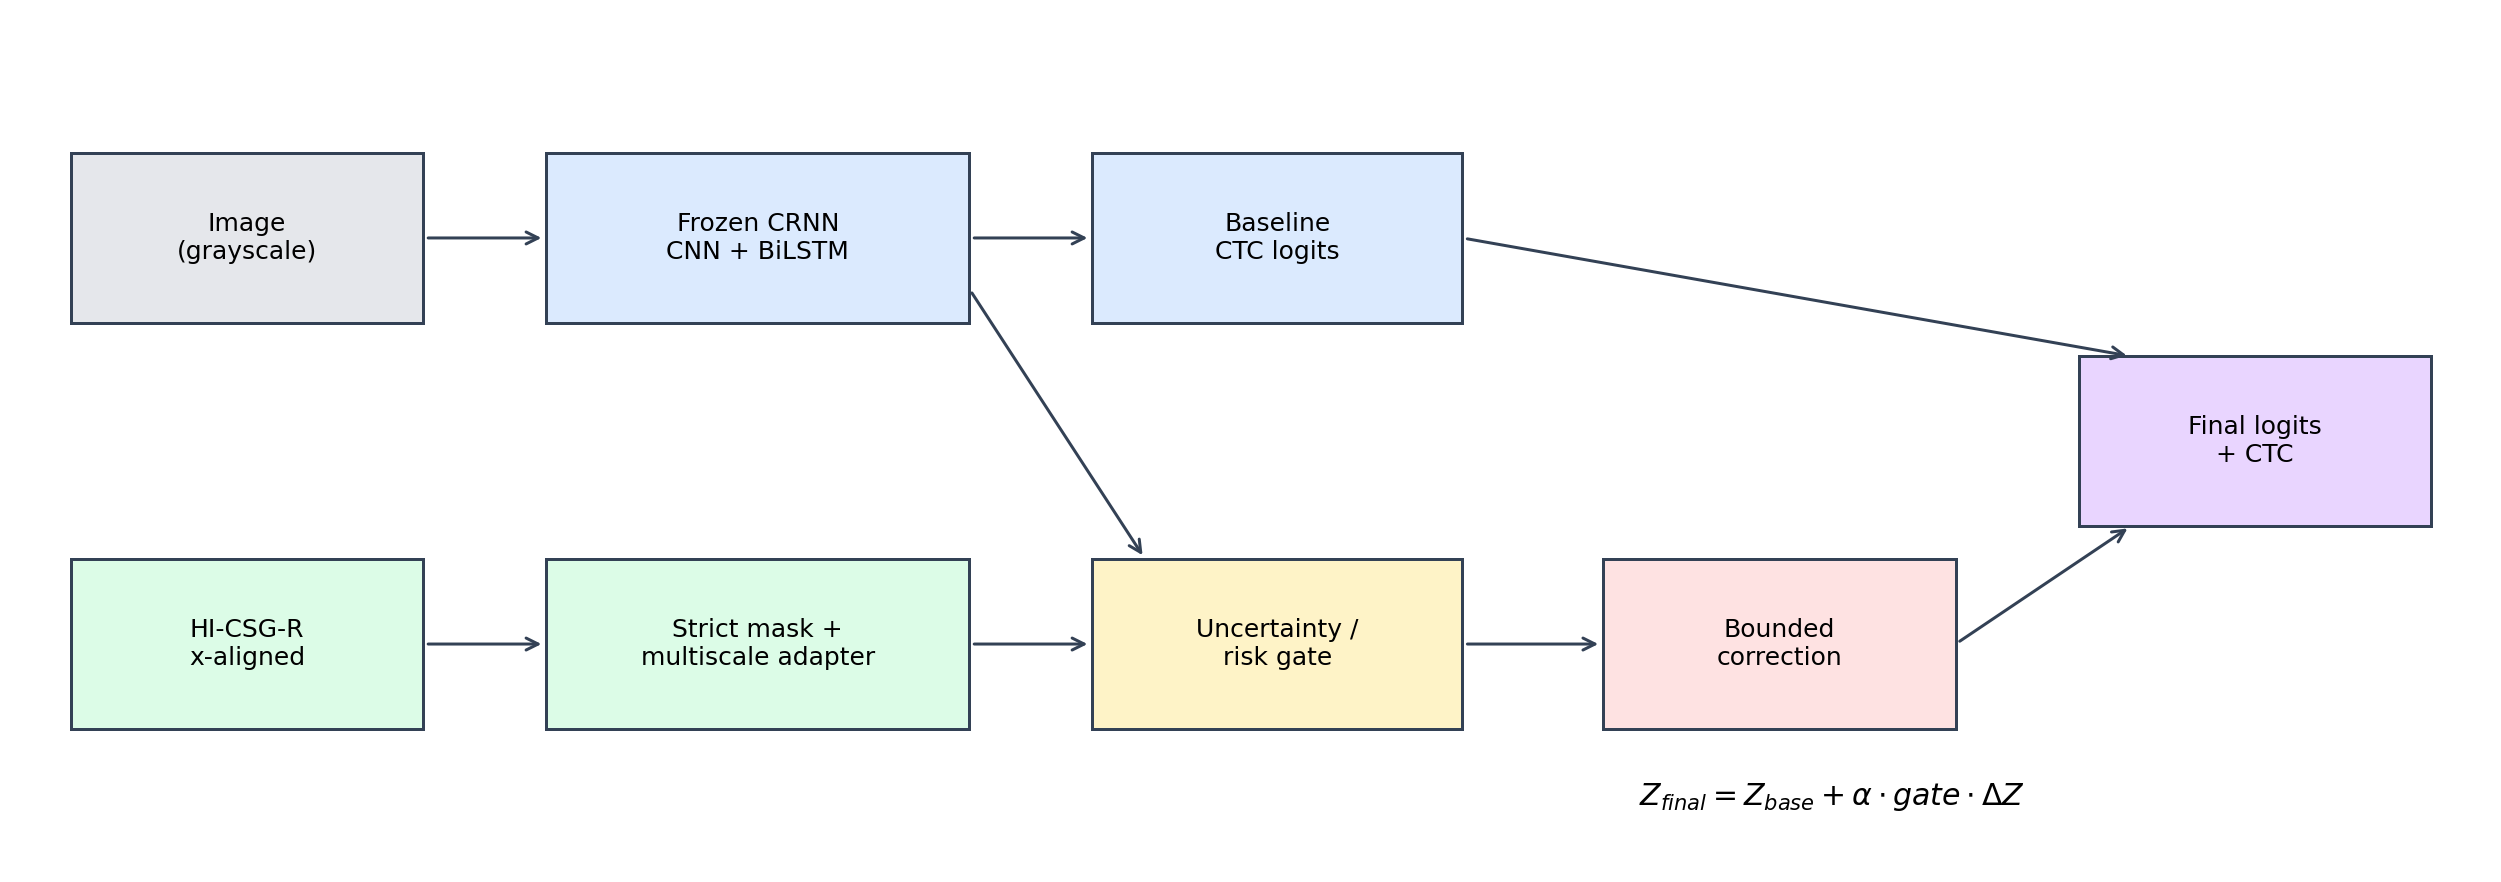

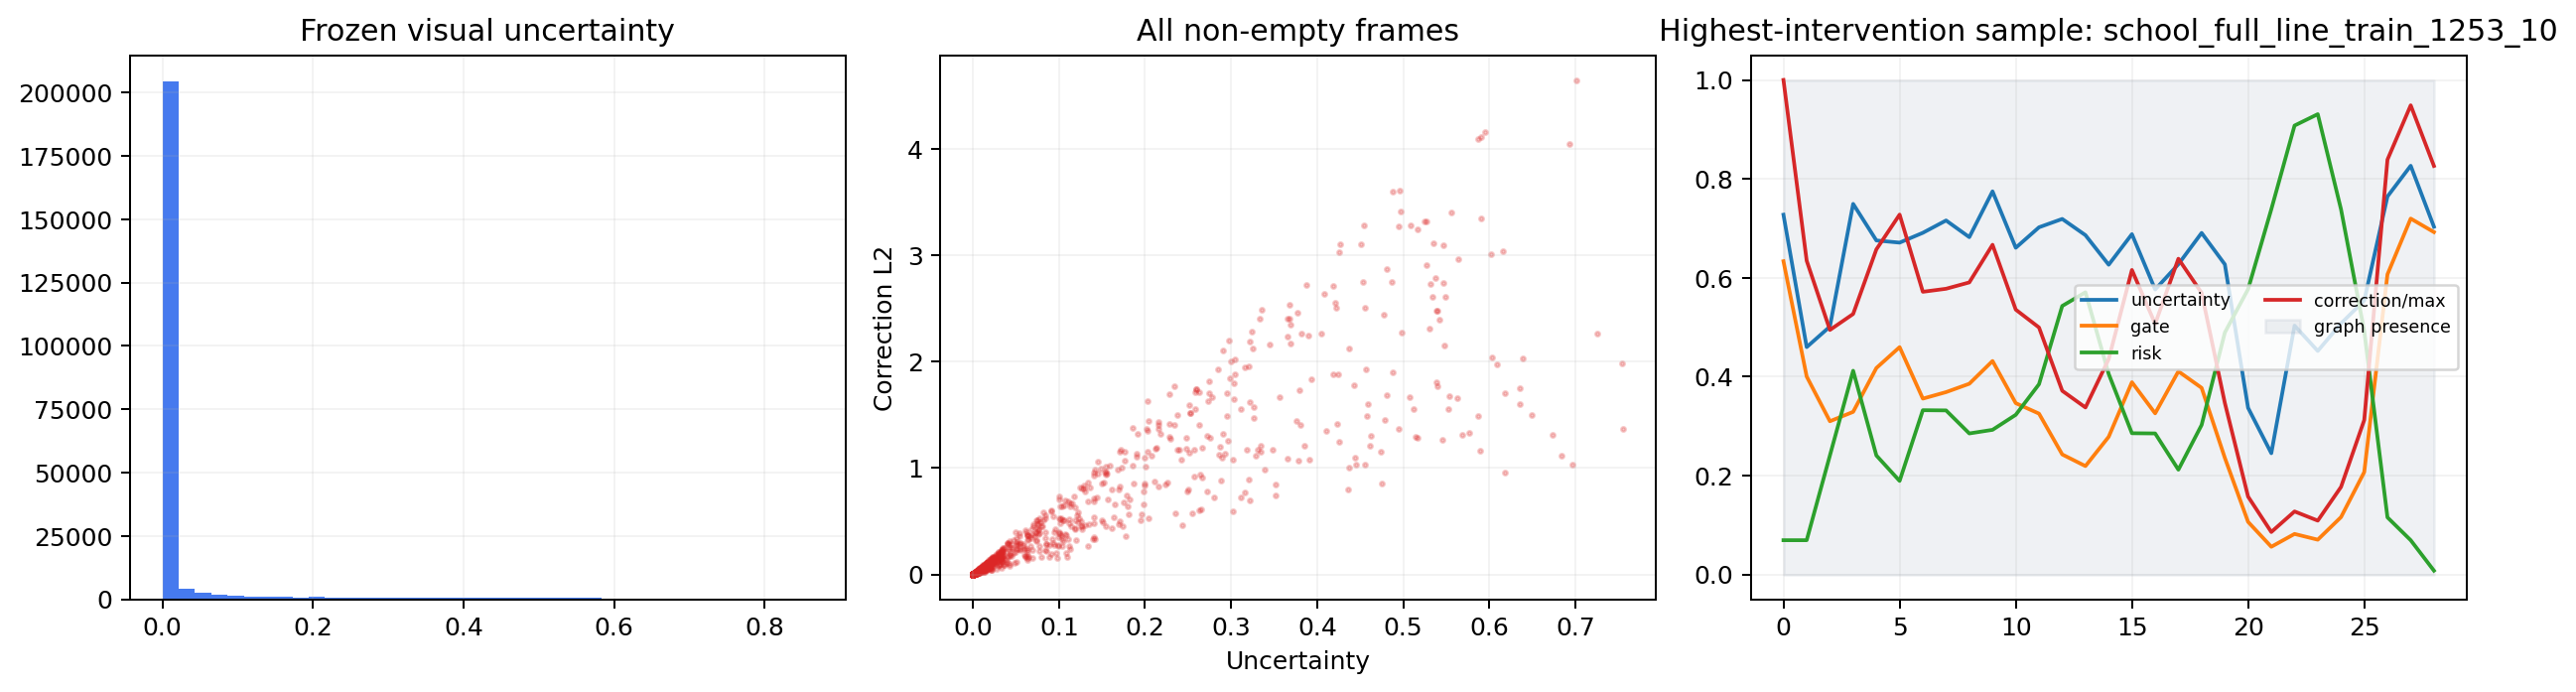

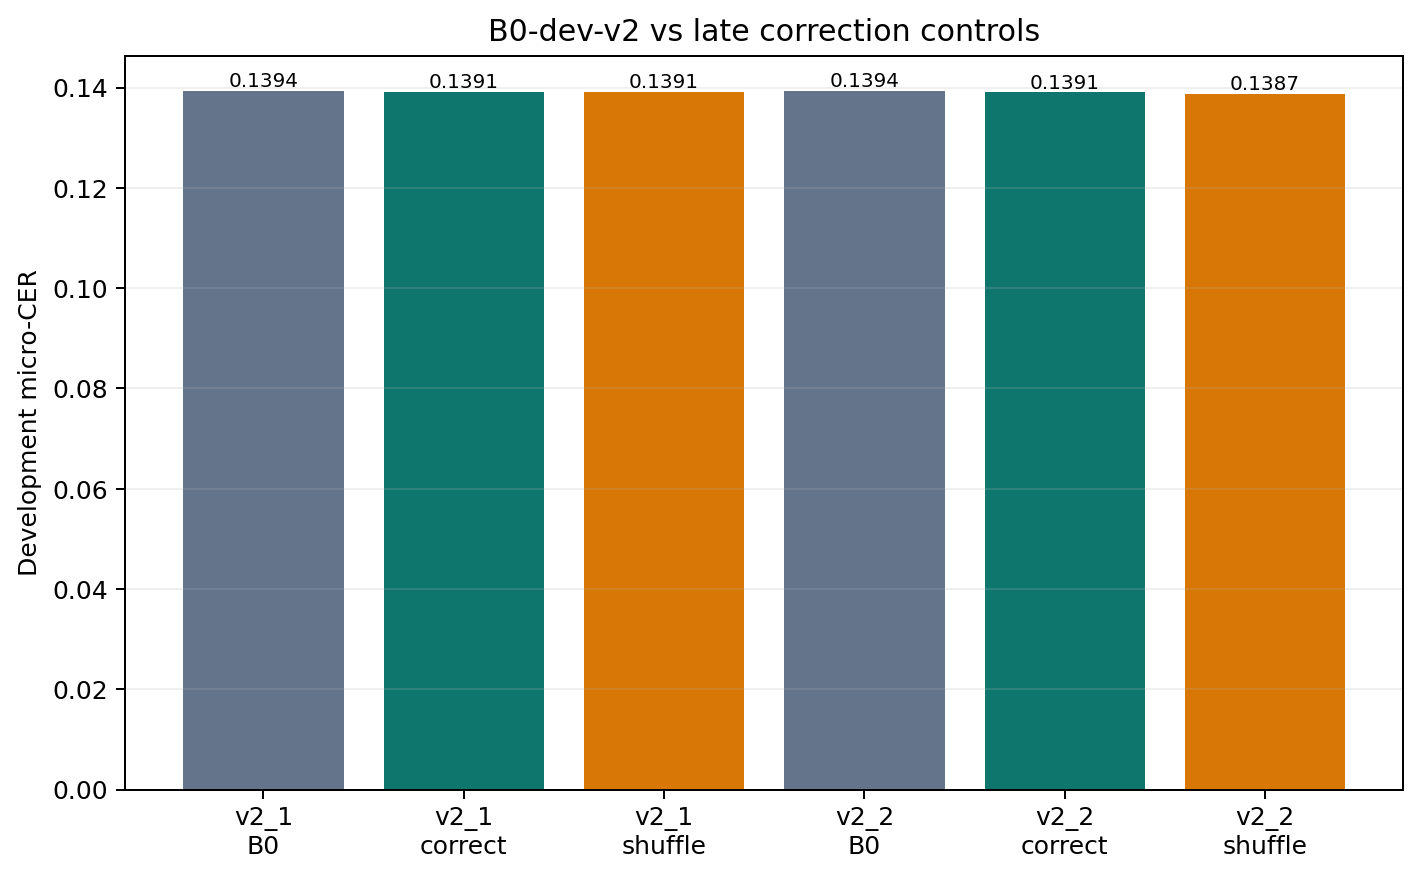

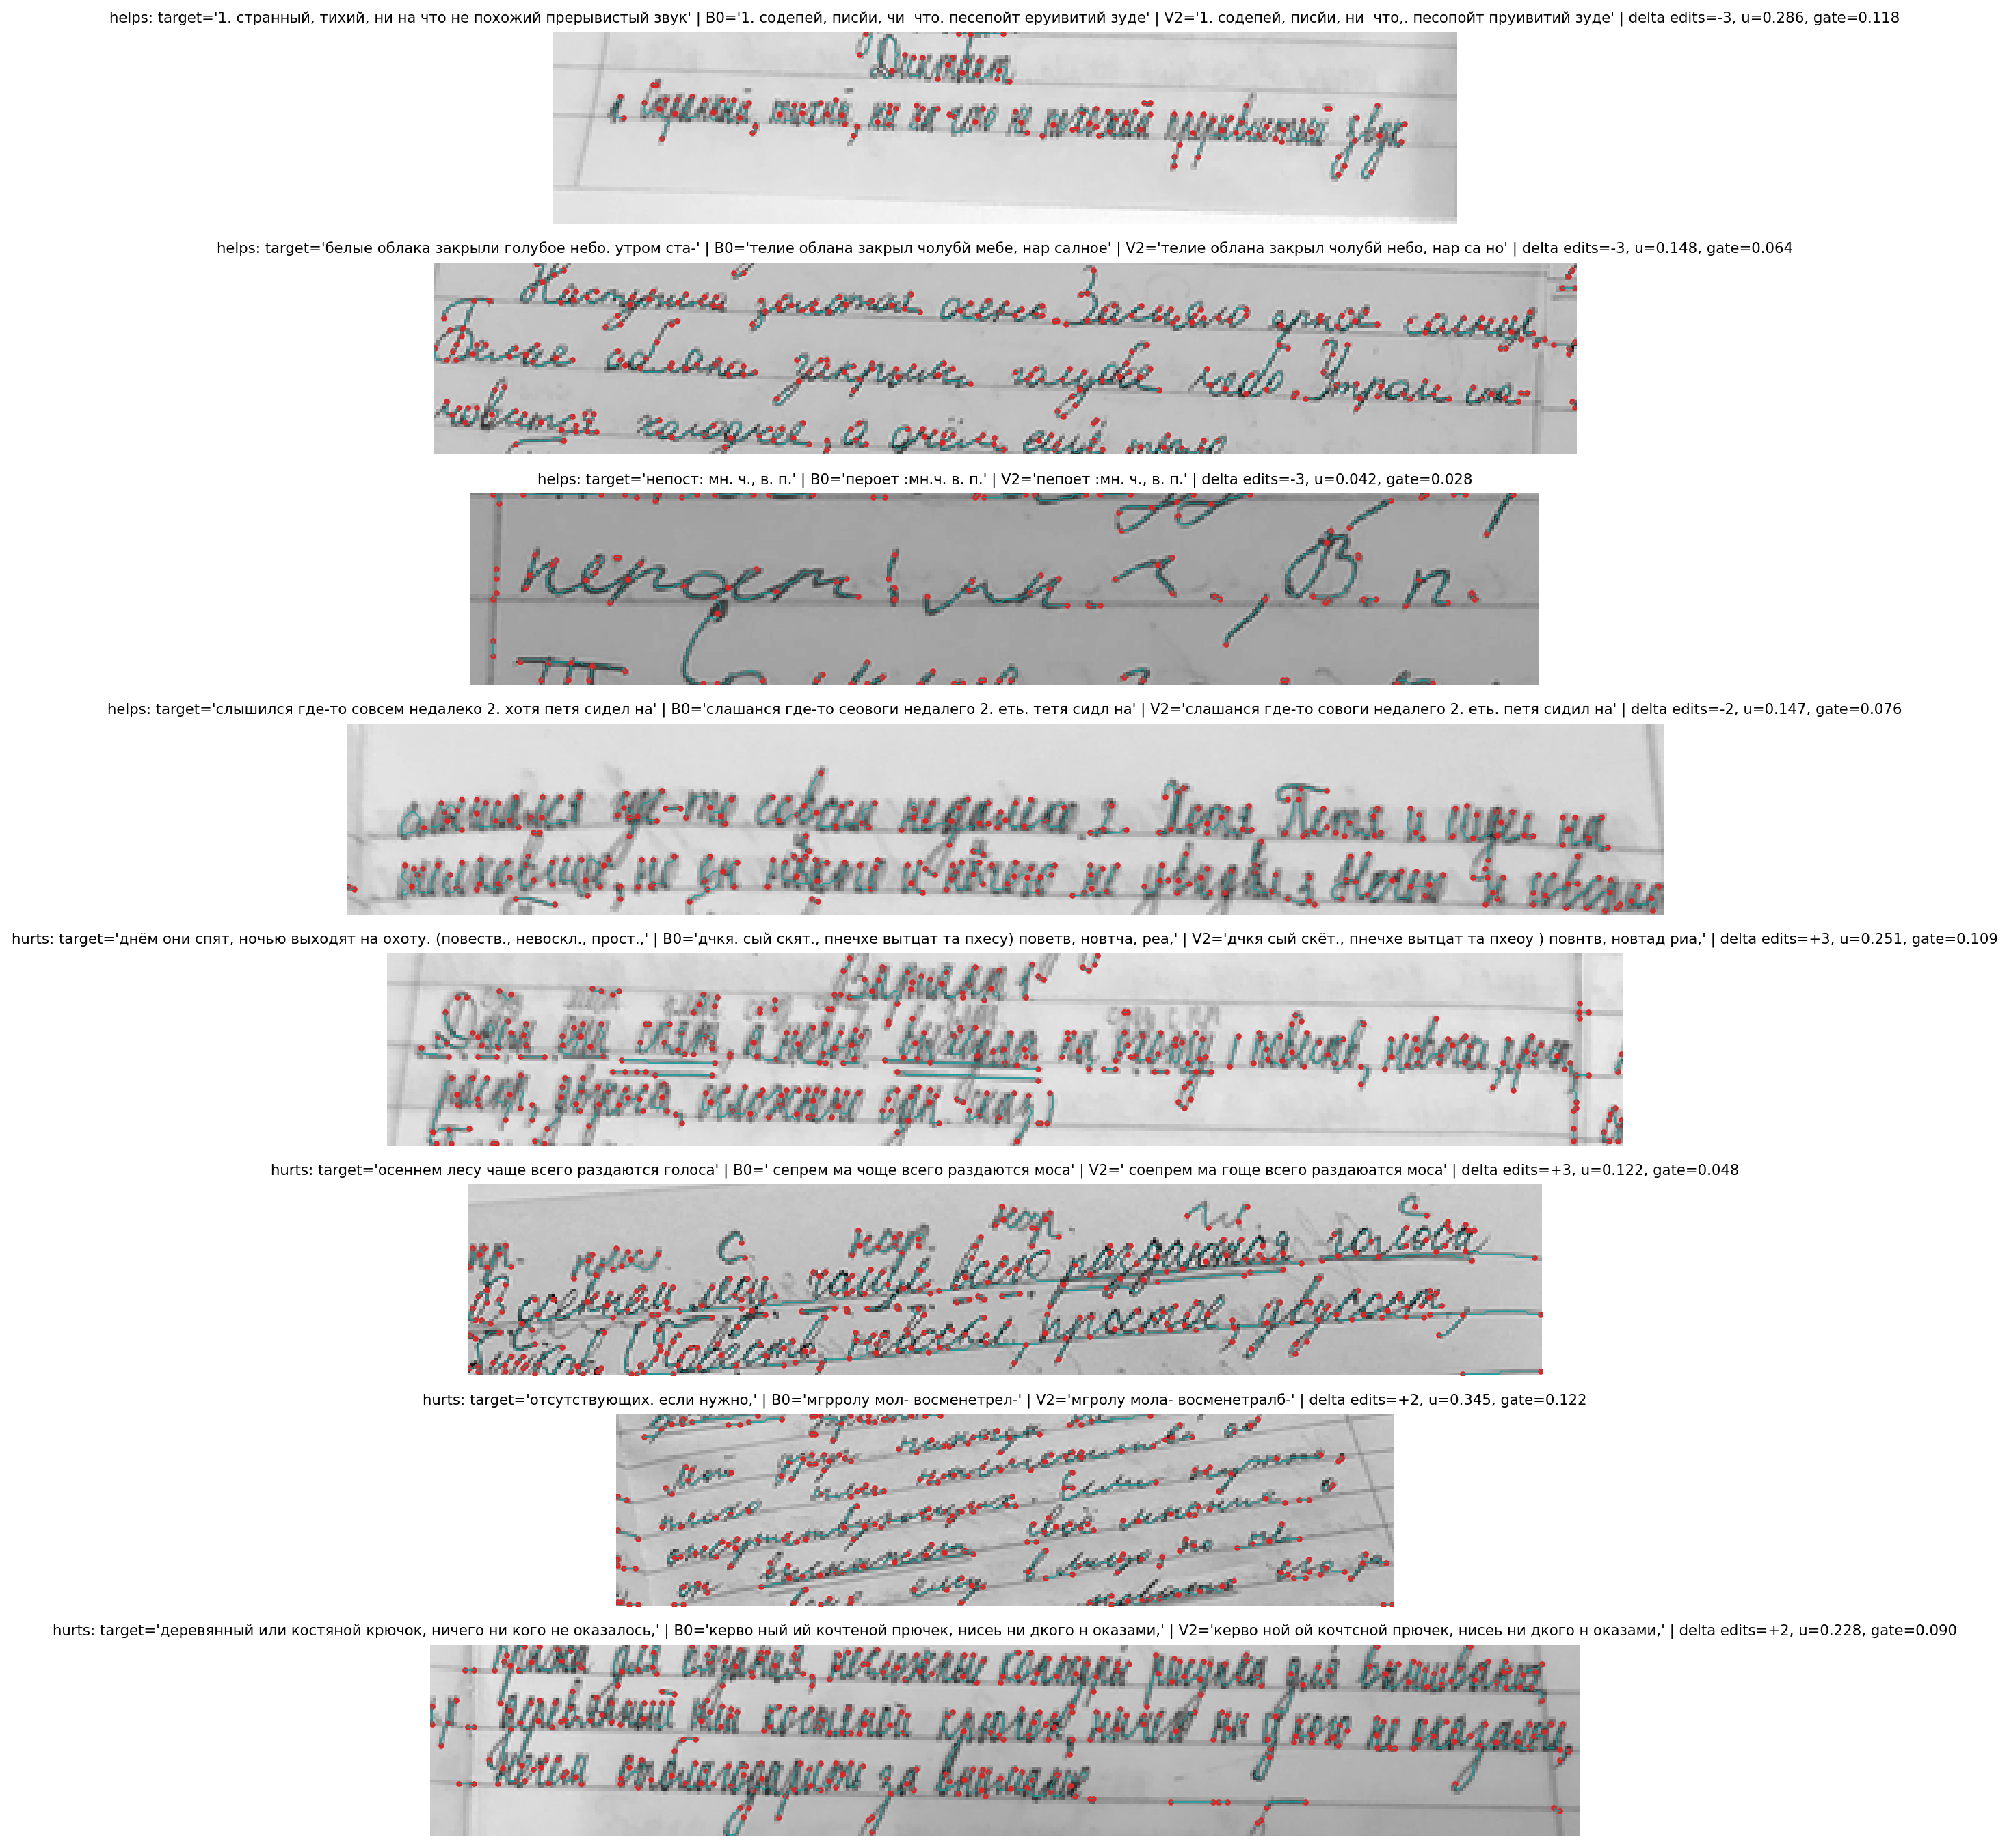

In [16]:
module(
    "tools.make_hi_csg_r_adapter_v2_final_report",
    "--root", OUT,
    "--out_dir", OUT / "final_report",
    log_name="final_report_v2",
)
full_report = OUT / "final_report/full_execution_report_ru.md"
display(Markdown(
    (
        full_report
        if full_report.exists()
        else OUT / "final_report/final_results.md"
    ).read_text(encoding="utf-8")
))
for name in (
    "figure_a_architecture.png",
    "figure_b_intervention.png",
    "figure_c_results.png",
    "figure_d_helps_hurts.png",
):
    path = OUT / "final_report" / name
    if path.exists():
        display(Image(filename=str(path)))


## Интерпретация

Научный статус определяется только dev/holdout/final gates. Технические
invariants, one-sample overfit, gradients, gate variability и zero-graph
dependency сами по себе не подтверждают H4-v2.
